# Mini-Projet : Gestion du Déséquilibre de Classes
## Analyse de Sentiments en Dialecte Algérien — TWIFL + DziriBERT
### Toutes les Étapes (checkpoint-aware)
---
> **Logique** : chaque étape détecte si son checkpoint `.pt` existe déjà.
> Si oui → on charge et on évalue directement. Si non → on entraîne.

In [4]:
!pip install datasets transformers torch scikit-learn matplotlib seaborn wordcloud emoji pandas numpy imbalanced-learn -q

In [6]:
import os, re, pickle, json, warnings, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud
from datasets import load_dataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, recall_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoModel,
    MarianMTModel, MarianTokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# ── Constants ─────────────────────────────────────────────────────────────────
TEXT_COL    = 'Post'
LANG_COL    = 'lang'
TARGET_COL  = 'Polarity Class'
CLASS_ORDER = ['Positive', 'Negative', 'Neutral']
COLORS      = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}
MODEL_NAME  = 'alger-ia/dziribert'
SEED        = 42
EPOCHS      = 5
LR          = 2e-5
BATCH_SIZE  = 16
MAX_LEN     = 128
NUM_LABELS  = 3

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

# ── Paths ─────────────────────────────────────────────────────────────────────
KAGGLE_INPUT_DIR = '/kaggle/input/models/fmyacine/ml/other/default/1'
WORK_DIR         = '/kaggle/working'   # where new checkpoints are saved

PRETRAINED_CKPTS = {
    'baseline_best.pt',
    'bt_20pct_best.pt',
    'bt_50pct_best.pt',
    'bt_100pct_best.pt',
    'cw_best.pt',
    'fl1_best.pt',
    'fl2_best.pt',
    # combined_best.pt is NOT here → will be trained
}

def ckpt_input(filename):
    """Path in Kaggle input directory (read-only, already trained)."""
    return os.path.join(KAGGLE_INPUT_DIR, filename)

def ckpt_output(filename):
    """Path in working directory (writable, new training)."""
    return os.path.join(WORK_DIR, filename)

def ckpt_exists(filename):
    """
    Check if a checkpoint exists.
    Priority: Kaggle input dir first (pre-trained), then working dir.
    Returns (exists: bool, path: str)
    """
    if filename in PRETRAINED_CKPTS:
        p = ckpt_input(filename)
        if os.path.isfile(p):
            return True, p
    p = ckpt_output(filename)
    return os.path.isfile(p), p

print('Checkpoint helper ready.')
print(f'Kaggle input dir : {KAGGLE_INPUT_DIR}')
print(f'Working dir      : {WORK_DIR}')



Device : cuda
Checkpoint helper ready.
Kaggle input dir : /kaggle/input/models/fmyacine/ml/other/default/1
Working dir      : /kaggle/working


## Utilitaires partagés (Dataset, métriques, entraînement)

In [7]:
class TwiflDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)}

def compute_gmean(y_true, y_pred):
    r = np.clip(recall_score(y_true, y_pred, average=None, labels=[0,1,2]), 1e-10, None)
    return float(np.exp(np.mean(np.log(r))))

def compute_auc_pr(y_true, y_proba):
    y_bin = label_binarize(y_true, classes=[0,1,2])
    return float(np.mean([average_precision_score(y_bin[:,i], y_proba[:,i]) for i in range(3)]))

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_proba = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            all_proba.extend(torch.softmax(out.logits, -1).cpu().numpy())
            all_preds.extend(torch.argmax(out.logits, -1).cpu().numpy())
            all_labels.extend(batch['label'].numpy())
    yt = np.array(all_labels); yp = np.array(all_preds); yb = np.array(all_proba)
    cnames = [id2label[i] for i in range(NUM_LABELS)]
    return {'f1_macro': f1_score(yt, yp, average='macro'),
            'f1_per_class': f1_score(yt, yp, average=None, labels=[0,1,2]),
            'auc_pr': compute_auc_pr(yt, yb), 'g_mean': compute_gmean(yt, yp),
            'confusion_matrix': confusion_matrix(yt, yp),
            'report': classification_report(yt, yp, target_names=cnames),
            'y_true': yt, 'y_pred': yp, 'y_proba': yb}

def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train(); total = 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['label'].to(device)
        optimizer.zero_grad()
        loss = criterion(model(input_ids=ids, attention_mask=mask).logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total += loss.item()
    return total / len(loader)

def resolve_ckpt(filename):
    """
    Returns (load_path_or_None, save_path).
    - load_path: where to load weights from (Kaggle input or working dir), or None if not found.
    - save_path: where to save new weights (always working dir).
    """
    # Check Kaggle input first (read-only, pre-trained)
    kaggle_path = os.path.join(KAGGLE_INPUT_DIR, filename)
    if os.path.isfile(kaggle_path):
        return kaggle_path, os.path.join(WORK_DIR, filename)
    # Check working dir (previously saved in this session)
    work_path = os.path.join(WORK_DIR, filename)
    if os.path.isfile(work_path):
        return work_path, work_path
    # Not found anywhere → needs training
    return None, work_path

def train_and_evaluate(criterion, config_name, ckpt_filename,
                       X_tr=None, y_tr=None, tokenizer=None,
                       max_len=MAX_LEN, epochs=EPOCHS):
    """Load from correct path if checkpoint exists, else train and save to working dir."""
    if X_tr is None: X_tr = X_train
    if y_tr is None: y_tr = y_train
    if tokenizer is None: tokenizer = main_tokenizer

    loader_tr   = DataLoader(TwiflDataset(X_tr,    y_tr,   tokenizer, max_len),
                             batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    loader_val  = DataLoader(TwiflDataset(X_val,   y_val,  tokenizer, max_len),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    loader_test = DataLoader(TwiflDataset(X_test,  y_test, tokenizer, max_len),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    torch.manual_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
    ).to(device)

    load_path, save_path = resolve_ckpt(ckpt_filename)

    if load_path is not None:
        print(f'  ✅ Checkpoint found → LOADING FROM: {load_path}')
        model.load_state_dict(torch.load(load_path, map_location=device), strict=False)
        tm = evaluate(model, loader_test)
        tm['train_losses'] = []; tm['val_f1s'] = []; tm['config_name'] = config_name
        return tm

    print(f'  🏋️  No checkpoint — training {config_name} → saving to {save_path}')
    optimizer   = AdamW(model.parameters(), lr=LR, eps=1e-8)
    total_steps = len(loader_tr) * epochs
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * 0.1), total_steps)

    train_losses, val_f1s, best_val_f1 = [], [], 0
    for epoch in range(1, epochs + 1):
        loss = train_epoch(model, loader_tr, optimizer, scheduler, criterion)
        vm   = evaluate(model, loader_val)
        train_losses.append(loss); val_f1s.append(vm['f1_macro'])
        print(f'    Epoch {epoch}/{epochs}  Loss: {loss:.4f}  Val F1-macro: {vm["f1_macro"]:.4f}')
        if vm['f1_macro'] > best_val_f1:
            best_val_f1 = vm['f1_macro']
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=device), strict=False)
    tm = evaluate(model, loader_test)
    tm['train_losses'] = train_losses; tm['val_f1s'] = val_f1s
    tm['config_name'] = config_name
    return tm

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha; self.reduction = reduction
    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        probs     = torch.exp(log_probs)
        pt        = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        log_pt    = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_w   = (1 - pt) ** self.gamma
        loss      = -focal_w * log_pt
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            loss    = alpha_t * loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()

print('Utilitaires définis.')
print('resolve_ckpt logic:')
print(f'  Kaggle input : {KAGGLE_INPUT_DIR}')
print(f'  Working dir  : {WORK_DIR}')


Utilitaires définis.
resolve_ckpt logic:
  Kaggle input : /kaggle/input/models/fmyacine/ml/other/default/1
  Working dir  : /kaggle/working


---
# ÉTAPE 1 — Analyse Exploratoire du Corpus TWIFL

In [8]:
dataset = load_dataset('arbml/Twifil')
df = dataset['train'].to_pandas()
print(f'Shape : {df.shape}')
df.head(3)


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001-eef2e32ea1bb4a(…):   0%|          | 0.00/699k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Shape : (6000, 16)


,ID,Code,Post,lang,Created At,Followers Count,Profile Link Color,Geo Enabled,Screen Name,Name,Profile Lang,Polarity,Polarity Class,User Age,Emotion,Platform
0,1,9.5283479986508e+17,@gamehacker080 @WaellAmeer @Kempa2010 @omeralb...,ar,Mon Jan 15 09:28:13 +0000 2018,215,0084B4,1,JackoTyga,Amine Jacko,fr,"3,43",Positive,26.0,nan,Twitter
1,2,9.5283475039334e+17,@arar12332095361 صل الله عليه و سلم,ar,Mon Jan 15 09:28:01 +0000 2018,1682,19CF86,1,aminoooo_amine,Amine Bourahla,fr,"7,14",Positive,26.0,nan,Twitter
2,3,9.5283463826695e+17,@SRKFC1 @iamsrk @gaurikhan 💖💖💖💖💖💖 https://t.co...,und,Mon Jan 15 09:27:35 +0000 2018,114,1DA1F2,1,FoufaKiri,Foufa kiri,fr,"3,33",Positive,nan,nan,Twitter


In [9]:
class_counts = df[TARGET_COL].value_counts()
class_pct    = df[TARGET_COL].value_counts(normalize=True) * 100
print('=== Distribution des classes ===')
for cls in CLASS_ORDER:
    print(f'  {cls:10s}: {class_counts[cls]:5d} tweets  ({class_pct[cls]:.1f}%)')
ratio = class_counts['Positive'] / class_counts['Neutral']
print(f'\nRatio Positive / Neutral : {ratio:.2f}')


=== Distribution des classes ===
  Positive  :  2864 tweets  (47.7%)
  Negative  :  1773 tweets  (29.5%)
  Neutral   :  1363 tweets  (22.7%)

Ratio Positive / Neutral : 2.10


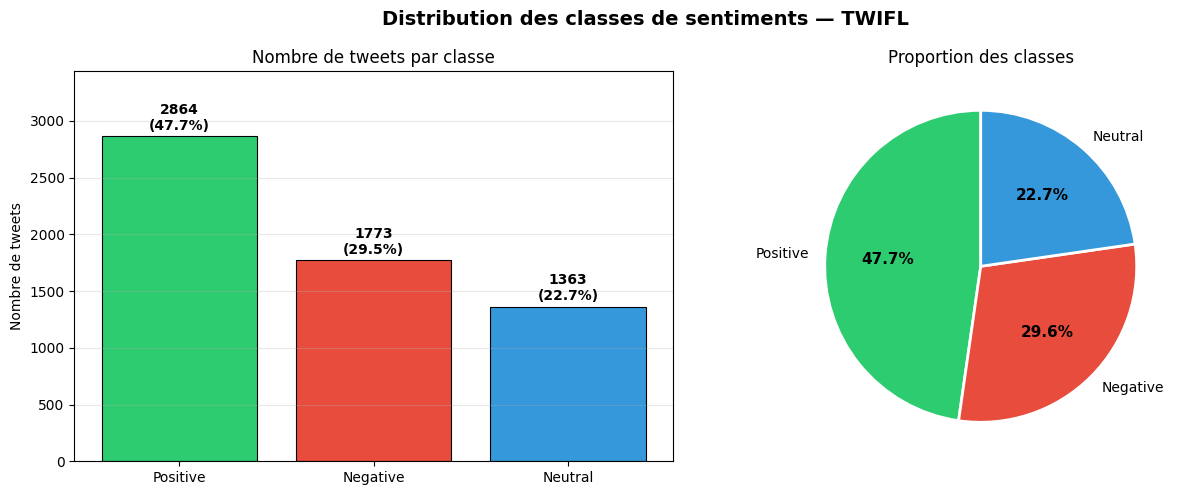

In [10]:
counts_list = [class_counts[c] for c in CLASS_ORDER]
pcts_list   = [class_pct[c]   for c in CLASS_ORDER]
colors_list = [COLORS[c]      for c in CLASS_ORDER]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution des classes de sentiments — TWIFL', fontsize=14, fontweight='bold')
bars = axes[0].bar(CLASS_ORDER, counts_list, color=colors_list, edgecolor='black', linewidth=0.8)
for bar, cnt, pct in zip(bars, counts_list, pcts_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_title('Nombre de tweets par classe'); axes[0].set_ylabel('Nombre de tweets')
axes[0].set_ylim(0, max(counts_list) * 1.2); axes[0].grid(axis='y', alpha=0.3)
wedges, texts, autotexts = axes[1].pie(counts_list, labels=CLASS_ORDER, autopct='%1.1f%%',
    colors=colors_list, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold')
axes[1].set_title('Proportion des classes')
plt.tight_layout(); plt.savefig('distribution_classes.png', dpi=150, bbox_inches='tight'); plt.show()


In [11]:
df['nb_mots']  = df[TEXT_COL].fillna('').apply(lambda x: len(str(x).split()))
df['nb_chars'] = df[TEXT_COL].fillna('').apply(lambda x: len(str(x)))
print('=== Longueur des tweets par classe ===')
print(df.groupby(TARGET_COL)[['nb_mots', 'nb_chars']].describe().round(1))

lang_dist = df[LANG_COL].value_counts()
lang_pct  = df[LANG_COL].value_counts(normalize=True) * 100
print('\n=== Top langues ===')
print(pd.DataFrame({'count': lang_dist, '%': lang_pct.round(1)}).head(10))

def has_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in str(text))
df['has_emoji'] = df[TEXT_COL].apply(has_emoji)
print(f'\nTweets avec emojis : {df["has_emoji"].mean()*100:.1f}%')

def has_arabic(t): return bool(re.search(r'[\u0600-\u06FF]', str(t)))
def has_latin(t):  return bool(re.search(r'[a-zA-Z]', str(t)))
df['code_switching'] = df[TEXT_COL].apply(lambda t: has_arabic(t) and has_latin(t))
print(f'Code-switching (arabe + latin) : {df["code_switching"].mean()*100:.1f}%')


=== Longueur des tweets par classe ===
               nb_mots                                        nb_chars        \
                 count  mean  std  min  25%   50%   75%   max    count  mean   
Polarity Class                                                                 
Negative        1773.0  13.5  6.9  1.0  7.0  14.0  19.0  33.0   1773.0  90.0   
Neutral         1363.0   5.7  6.5  1.0  1.0   2.0   9.0  30.0   1363.0  56.3   
Positive        2864.0   9.9  7.0  1.0  4.0   8.0  15.0  32.0   2864.0  71.9   

                                                     
                 std  min   25%   50%    75%    max  
Polarity Class                                       
Negative        42.3  3.0  50.0  91.0  139.0  140.0  
Neutral         44.0  3.0  23.0  34.0   83.0  151.0  
Positive        42.8  1.0  35.0  58.5  113.0  144.0  

=== Top langues ===
      count     %
lang             
ar     2462  41.0
und    1244  20.7
fr     1110  18.5
en      733  12.2
es       94   1.6
in       

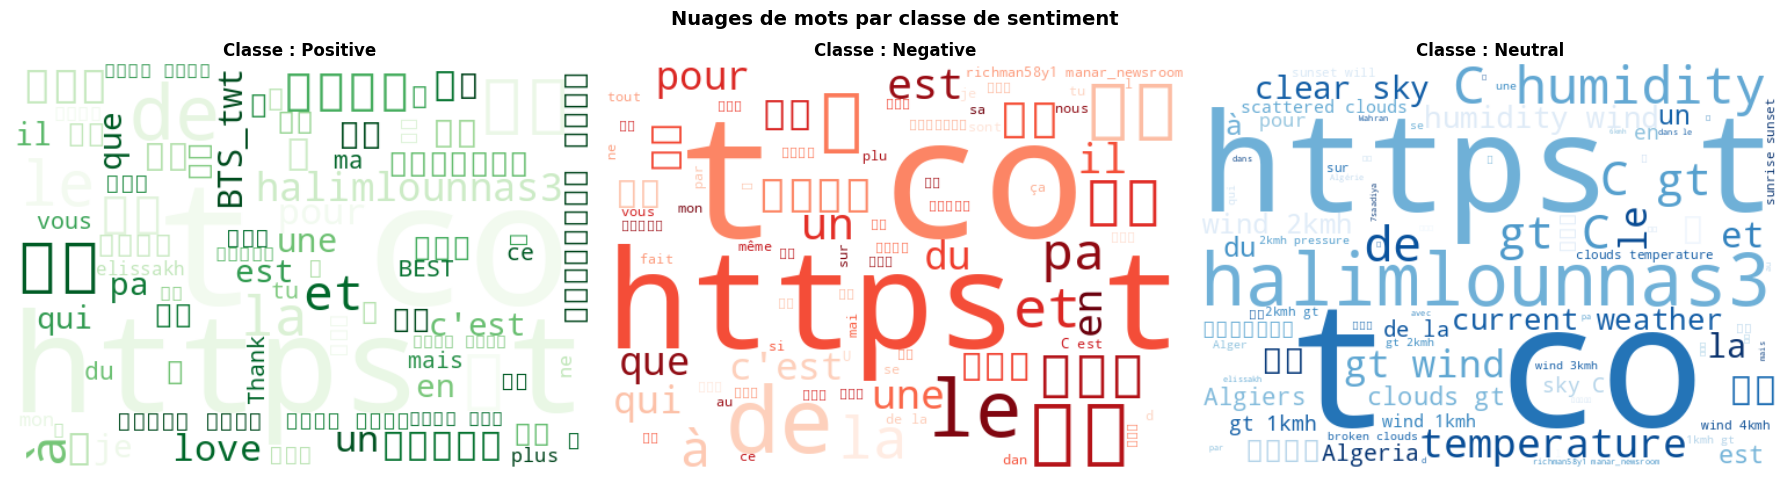

In [12]:
# WordCloud par classe
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Nuages de mots par classe de sentiment', fontsize=14, fontweight='bold')
cmap_map = {'Positive': 'Greens', 'Negative': 'Reds', 'Neutral': 'Blues'}
for ax, cls in zip(axes, CLASS_ORDER):
    texts = ' '.join(df[df[TARGET_COL] == cls][TEXT_COL].dropna().astype(str))
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap_map[cls], max_words=80).generate(texts)
    ax.imshow(wc, interpolation='bilinear'); ax.set_title(f'Classe : {cls}', fontsize=12, fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight'); plt.show()


---
# ÉTAPE 2 — Prétraitement & Split

In [13]:
def clean_tweet(text):
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'^RT\s*', '', text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077Fa-zA-Z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_darija(text):
    if not text: return text
    text = re.sub(r'([\u0600-\u06FF])\1{2,}', r'\1\1', text)
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text)
    text = re.sub(r'[أإآ]', 'ا', text)
    text = re.sub(r'[\u064B-\u065F\u0610-\u061A\u06D6-\u06DC]', '', text)
    for ar, w in zip('٠١٢٣٤٥٦٧٨٩', '0123456789'):
        text = text.replace(ar, w)
    return text.strip()

def full_preprocessing(text):
    return normalize_darija(clean_tweet(text))

df['text_clean'] = df[TEXT_COL].apply(full_preprocessing)
n0 = len(df)
df = df.drop_duplicates(subset=['text_clean']).copy()
print(f'Doublons supprimés : {n0 - len(df)}')
df = df[df['text_clean'].str.strip().str.len() > 0].copy()
print(f'Total restant : {len(df)}')


Doublons supprimés : 1302
Total restant : 4697


In [14]:
# ── Split stratifié 70/15/15 ──────────────────────────────────────────────────
# Kaggle input has 'splits (1).pkl'; working dir uses 'splits.pkl'
SPLITS_KAGGLE = os.path.join(KAGGLE_INPUT_DIR, 'splits (1).pkl')
SPLITS_FILE   = os.path.join(WORK_DIR, 'splits.pkl')

label2id = {'Positive': 0, 'Negative': 1, 'Neutral': 2}
id2label = {v: k for k, v in label2id.items()}

if os.path.isfile(SPLITS_KAGGLE) or os.path.isfile(SPLITS_FILE):
    src = SPLITS_KAGGLE if os.path.isfile(SPLITS_KAGGLE) else SPLITS_FILE
    print(f'✅ Splits trouvés : {src} — chargement.')
    with open(src, 'rb') as f:
        splits = pickle.load(f)
    X_train, y_train = splits['X_train'], splits['y_train']
    X_val,   y_val   = splits['X_val'],   splits['y_val']
    X_test,  y_test  = splits['X_test'],  splits['y_test']
    label2id = splits['label2id']; id2label = splits['id2label']
else:
    print('🏋️  Création du split...')
    df['label'] = df[TARGET_COL].map(label2id)
    X = df['text_clean'].values; y = df['label'].values
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
    X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)
    with open(os.path.join(WORK_DIR, 'splits.pkl'), 'wb') as f:
        pickle.dump({'X_train': X_train, 'y_train': y_train,
                     'X_val': X_val, 'y_val': y_val,
                     'X_test': X_test, 'y_test': y_test,
                     'label2id': label2id, 'id2label': id2label}, f)
    print(f'Splits sauvegardés dans {SPLITS_FILE}')

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')
for name, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    c = Counter(y_s)
    print(f'  {name}: ' + ', '.join(f'{id2label[k]}: {v} ({v/len(y_s)*100:.1f}%)' for k, v in sorted(c.items())))

# Tokenizer principal (partagé par toutes les étapes)
main_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_loaders(X_tr=None, y_tr=None, max_len=MAX_LEN):
    if X_tr is None: X_tr = X_train
    if y_tr is None: y_tr = y_train
    return (DataLoader(TwiflDataset(X_tr, y_tr, main_tokenizer, max_len), batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
            DataLoader(TwiflDataset(X_val, y_val, main_tokenizer, max_len), batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
            DataLoader(TwiflDataset(X_test, y_test, main_tokenizer, max_len), batch_size=BATCH_SIZE, shuffle=False, num_workers=0))

train_loader, val_loader, test_loader = make_loaders()
print(f'Loaders créés.')


✅ Splits trouvés : /kaggle/input/models/fmyacine/ml/other/default/1/splits (1).pkl — chargement.
Train : 3287 | Val : 705 | Test : 705
  Train: Positive: 1671 (50.8%), Negative: 1185 (36.1%), Neutral: 431 (13.1%)
  Val: Positive: 358 (50.8%), Negative: 254 (36.0%), Neutral: 93 (13.2%)
  Test: Positive: 359 (50.9%), Negative: 254 (36.0%), Neutral: 92 (13.0%)


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaders créés.


---
# ÉTAPE 3 — Baseline DziriBERT

In [ ]:
criterion_bl = nn.CrossEntropyLoss()
print('=== Baseline ===')
metrics_bl = train_and_evaluate(criterion_bl, 'Baseline', 'baseline_best.pt')
f1p = metrics_bl['f1_per_class']
print(f'Test F1-macro: {metrics_bl["f1_macro"]:.4f} | AUC-PR: {metrics_bl["auc_pr"]:.4f} | G-mean: {metrics_bl["g_mean"]:.4f}')
for i, name in id2label.items(): print(f'  F1 {name:10s}: {f1p[i]:.4f}')


In [ ]:
# Initialise le fichier JSON de résultats
result_bl = {'configuration': 'Baseline (données brutes)',
              'f1_macro': round(metrics_bl['f1_macro'],4),
              'f1_positive': round(f1p[0],4), 'f1_negative': round(f1p[1],4),
              'f1_neutral': round(f1p[2],4), 'auc_pr': round(metrics_bl['auc_pr'],4),
              'g_mean': round(metrics_bl['g_mean'],4)}
all_results = [result_bl]
with open(os.path.join(WORK_DIR, 'results_comparison.json'), 'w') as f: json.dump(all_results, f, indent=2, ensure_ascii=False)
print('✅ results_comparison.json initialisé')
print(pd.DataFrame([result_bl]).to_string(index=False))


---
# ÉTAPE 4 — Stratégie 1 : Modification de la Perte

In [ ]:
# Class weights
train_counts = Counter(y_train); total_train = len(y_train)
class_weights = torch.tensor(
    [total_train / (NUM_LABELS * train_counts[i]) for i in range(NUM_LABELS)],
    dtype=torch.float32).to(device)
print('Class weights :', {id2label[i]: round(class_weights[i].item(), 4) for i in range(NUM_LABELS)})

# ── Class Weighting ────────────────────────────────────────────────────────────
print('\n=== Class Weighting ===')
metrics_cw = train_and_evaluate(nn.CrossEntropyLoss(weight=class_weights), 'Class Weighting', 'cw_best.pt')
f1p = metrics_cw['f1_per_class']
print(f'Test F1-macro: {metrics_cw["f1_macro"]:.4f} | AUC-PR: {metrics_cw["auc_pr"]:.4f} | G-mean: {metrics_cw["g_mean"]:.4f}')
for i in range(NUM_LABELS): print(f'  F1 {id2label[i]:10s}: {f1p[i]:.4f}')

# ── Focal Loss γ=1 ────────────────────────────────────────────────────────────
print('\n=== Focal Loss (γ=1) ===')
metrics_fl1 = train_and_evaluate(FocalLoss(gamma=1.0), 'Focal Loss (γ=1)', 'fl1_best.pt')
f1p = metrics_fl1['f1_per_class']
print(f'Test F1-macro: {metrics_fl1["f1_macro"]:.4f} | AUC-PR: {metrics_fl1["auc_pr"]:.4f} | G-mean: {metrics_fl1["g_mean"]:.4f}')
for i in range(NUM_LABELS): print(f'  F1 {id2label[i]:10s}: {f1p[i]:.4f}')

# ── Focal Loss γ=2 ────────────────────────────────────────────────────────────
print('\n=== Focal Loss (γ=2) ===')
metrics_fl2 = train_and_evaluate(FocalLoss(gamma=2.0), 'Focal Loss (γ=2)', 'fl2_best.pt')
f1p = metrics_fl2['f1_per_class']
print(f'Test F1-macro: {metrics_fl2["f1_macro"]:.4f} | AUC-PR: {metrics_fl2["auc_pr"]:.4f} | G-mean: {metrics_fl2["g_mean"]:.4f}')
for i in range(NUM_LABELS): print(f'  F1 {id2label[i]:10s}: {f1p[i]:.4f}')

# ── Focal Loss γ=2 + Class Weighting ─────────────────────────────────────────
print('\n=== Focal Loss γ=2 + Class Weighting ===')
metrics_comb = train_and_evaluate(FocalLoss(gamma=2.0, alpha=class_weights.cpu()),
                                  'Focal Loss γ=2 + Class Weighting', 'combined_best.pt')
f1p = metrics_comb['f1_per_class']
print(f'Test F1-macro: {metrics_comb["f1_macro"]:.4f} | AUC-PR: {metrics_comb["auc_pr"]:.4f} | G-mean: {metrics_comb["g_mean"]:.4f}')
for i in range(NUM_LABELS): print(f'  F1 {id2label[i]:10s}: {f1p[i]:.4f}')


In [54]:
# Tableau comparatif Étape 4
rows = [{'Configuration': 'Baseline',
         'F1-macro': result_bl['f1_macro'], 'F1 Positive': result_bl['f1_positive'],
         'F1 Negative': result_bl['f1_negative'], 'F1 Neutral': result_bl['f1_neutral'],
         'AUC-PR': result_bl['auc_pr'], 'G-mean': result_bl['g_mean']}]

for name, m in [('Class Weighting', metrics_cw), ('Focal Loss (γ=1)', metrics_fl1),
                ('Focal Loss (γ=2)', metrics_fl2), ('FL γ=2 + CW', metrics_comb)]:
    f1p = m['f1_per_class']
    rows.append({'Configuration': name, 'F1-macro': round(m['f1_macro'],4),
                 'F1 Positive': round(f1p[0],4), 'F1 Negative': round(f1p[1],4),
                 'F1 Neutral': round(f1p[2],4), 'AUC-PR': round(m['auc_pr'],4), 'G-mean': round(m['g_mean'],4)})
df_results4 = pd.DataFrame(rows)
print('=== TABLEAU COMPARATIF — ÉTAPE 4 ===')
print(df_results4.to_string(index=False))

# Sauvegarder
for name, m in [('Class Weighting', metrics_cw), ('Focal Loss (γ=1)', metrics_fl1),
                ('Focal Loss (γ=2)', metrics_fl2), ('FL γ=2 + CW', metrics_comb)]:
    f1p = m['f1_per_class']
    all_results.append({'configuration': name, 'f1_macro': round(m['f1_macro'],4),
                        'f1_positive': round(f1p[0],4), 'f1_negative': round(f1p[1],4),
                        'f1_neutral': round(f1p[2],4), 'auc_pr': round(m['auc_pr'],4), 'g_mean': round(m['g_mean'],4)})
with open(os.path.join(WORK_DIR, 'results_comparison.json'), 'w') as f: json.dump(all_results, f, indent=2, ensure_ascii=False)
print('✅ results_comparison.json mis à jour')


=== TABLEAU COMPARATIF — ÉTAPE 4 ===
   Configuration  F1-macro  F1 Positive  F1 Negative  F1 Neutral  AUC-PR  G-mean
        Baseline    0.6350       0.7538       0.6790      0.4722  0.7266  0.5815
 Class Weighting    0.6163       0.7085       0.6639      0.4766  0.7259  0.6522
Focal Loss (γ=1)    0.6365       0.7541       0.6723      0.4832  0.7275  0.5879
Focal Loss (γ=2)    0.6340       0.7529       0.6723      0.4768  0.7259  0.5861
     FL γ=2 + CW    0.6474       0.7480       0.6638      0.5304  0.7046  0.6323
✅ results_comparison.json mis à jour


---
# ÉTAPE 5 — Stratégie 2 : SMOTE / ADASYN sur Embeddings DziriBERT

In [15]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, ADASYN

# ── Embeddings ────────────────────────────────────────────────────────────────
EMB_FILE = os.path.join(WORK_DIR, 'train_embeddings.pkl')

def extract_cls_embeddings(texts, tokenizer, batch_size=32, max_len=64):
    bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
    bert.eval()
    all_emb = []
    ds     = TwiflDataset(texts, [0]*len(texts), tokenizer, max_len)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    total  = len(loader)
    with torch.no_grad():
        for i, batch in enumerate(loader, 1):
            out = bert(input_ids=batch['input_ids'].to(device),
                       attention_mask=batch['attention_mask'].to(device))
            all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
            if i % 20 == 0 or i == total:
                print(f'  Batch {i}/{total}', end='\r')
    print()
    return np.vstack(all_emb)

if os.path.isfile(EMB_FILE):
    print(f'✅ {EMB_FILE} trouvé — chargement.')
    with open(EMB_FILE, 'rb') as f:
        emb_data = pickle.load(f)
    emb_train = emb_data['embeddings']
else:
    print(f'🏋️  Extraction des embeddings DziriBERT sur {len(X_train)} tweets...')
    emb_train = extract_cls_embeddings(X_train, main_tokenizer)
    with open(EMB_FILE, 'wb') as f:
        pickle.dump({'embeddings': emb_train, 'labels': y_train, 'texts': X_train}, f)
    print(f'✅ Sauvegardé dans {EMB_FILE}')

print(f'Embedding shape: {emb_train.shape}')


🏋️  Extraction des embeddings DziriBERT sur 3287 tweets...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Batch 103/103
✅ Sauvegardé dans /kaggle/working/train_embeddings.pkl
Embedding shape: (3287, 768)


In [16]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, ADASYN

# ── Embeddings ────────────────────────────────────────────────────────────────
EMB_FILE = os.path.join(WORK_DIR, 'train_embeddings.pkl')

def extract_cls_embeddings(texts, tokenizer, batch_size=32, max_len=64):
    bert = AutoModel.from_pretrained(MODEL_NAME).to(device); bert.eval()
    all_emb = []
    ds = TwiflDataset(texts, [0]*len(texts), tokenizer, max_len)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    with torch.no_grad():
        for batch in loader:
            out = bert(input_ids=batch['input_ids'].to(device),
                       attention_mask=batch['attention_mask'].to(device))
            all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(all_emb)

if ckpt_exists(EMB_FILE):
    print(f'✅ {EMB_FILE} trouvé — chargement.')
    with open(EMB_FILE, 'rb') as f:
        emb_data = pickle.load(f)
    emb_train = emb_data['embeddings']
else:
    print('🏋️  Extraction des embeddings DziriBERT...')
    emb_train = extract_cls_embeddings(X_train, main_tokenizer)
    with open(EMB_FILE, 'wb') as f:
        pickle.dump({'embeddings': emb_train, 'labels': y_train, 'texts': X_train}, f)
    print(f'Sauvegardé dans {EMB_FILE}')

print(f'Embedding shape: {emb_train.shape}')


✅ /kaggle/working/train_embeddings.pkl trouvé — chargement.
Embedding shape: (3287, 768)


In [62]:
# ── Augmentation SMOTE / ADASYN ───────────────────────────────────────────────
SMOTE_FILE  = os.path.join(WORK_DIR, 'smote_data.pkl')
ADASYN_FILE = os.path.join(WORK_DIR, 'adasyn_data.pkl')

def synthetic_to_texts(emb_aug, y_aug, emb_real, texts_real, y_real):
    n_real = len(y_real); emb_synth = emb_aug[n_real:]; y_synth = y_aug[n_real:]
    nbrs = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(emb_real)
    _, indices = nbrs.kneighbors(emb_synth)
    texts_synth = np.array([texts_real[idx[0]] for idx in indices])
    return np.concatenate([texts_real, texts_synth]), np.concatenate([y_real, y_synth])

N_PCA = 249
pca = PCA(n_components=N_PCA, random_state=SEED)
emb_pca = pca.fit_transform(emb_train)
print(f'PCA: 768 → {N_PCA} dims ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)')

if os.path.isfile(SMOTE_FILE):
    print(f'✅ {SMOTE_FILE} trouvé — chargement.')
    with open(SMOTE_FILE, 'rb') as f: smote_data = pickle.load(f)
    X_smote_text, y_smote_text = smote_data['X_aug'], smote_data['y_aug']
else:
    print('🏋️  Application SMOTE...')
    smote = SMOTE(k_neighbors=5, random_state=SEED, sampling_strategy='minority')
    emb_smote, y_smote_emb = smote.fit_resample(emb_pca, y_train)
    X_smote_text, y_smote_text = synthetic_to_texts(emb_smote, y_smote_emb, emb_pca, X_train, y_train)
    with open(SMOTE_FILE, 'wb') as f: pickle.dump({'X_aug': X_smote_text, 'y_aug': y_smote_text}, f)
    print(f'Sauvegardé {SMOTE_FILE}')

if os.path.isfile(ADASYN_FILE):
    print(f'✅ {ADASYN_FILE} trouvé — chargement.')
    with open(ADASYN_FILE, 'rb') as f: adasyn_data = pickle.load(f)
    X_adasyn_text, y_adasyn_text = adasyn_data['X_aug'], adasyn_data['y_aug']
else:
    print('🏋️  Application ADASYN...')
    adasyn = ADASYN(n_neighbors=5, random_state=SEED, sampling_strategy='minority')
    emb_adasyn, y_adasyn_emb = adasyn.fit_resample(emb_pca, y_train)
    X_adasyn_text, y_adasyn_text = synthetic_to_texts(emb_adasyn, y_adasyn_emb, emb_pca, X_train, y_train)
    with open(ADASYN_FILE, 'wb') as f: pickle.dump({'X_aug': X_adasyn_text, 'y_aug': y_adasyn_text}, f)
    print(f'Sauvegardé {ADASYN_FILE}')

print(f'SMOTE train: {len(X_smote_text)} | dist: {dict(Counter(y_smote_text))}')
print(f'ADASYN train: {len(X_adasyn_text)} | dist: {dict(Counter(y_adasyn_text))}')

PCA: 768 → 249 dims (95.0% variance)
🏋️  Application SMOTE...
Sauvegardé /kaggle/working/smote_data.pkl
🏋️  Application ADASYN...
Sauvegardé /kaggle/working/adasyn_data.pkl
SMOTE train: 4527 | dist: {np.int64(0): 1671, np.int64(1): 1185, np.int64(2): 1671}
ADASYN train: 4630 | dist: {np.int64(0): 1671, np.int64(1): 1185, np.int64(2): 1774}


In [63]:
PROF_PARAMS = {'lr': 2e-5, 'warmup_ratio': 0.10, 'max_len': 128, 'weight_decay': 0.0, 'label_smoothing': 0.0}

print('=== SMOTE + DziriBERT ===')
metrics_smote = train_and_evaluate(nn.CrossEntropyLoss(), 'SMOTE + DziriBERT', 'smote_prof_best.pt',
                                   X_tr=X_smote_text, y_tr=y_smote_text)
f1p = metrics_smote['f1_per_class']
print(f'Test F1-macro: {metrics_smote["f1_macro"]:.4f} | F1-Neutral: {f1p[2]:.4f} | G-mean: {metrics_smote["g_mean"]:.4f}')

print('\n=== ADASYN + DziriBERT ===')
metrics_adasyn = train_and_evaluate(nn.CrossEntropyLoss(), 'ADASYN + DziriBERT', 'adasyn_prof_best.pt',
                                    X_tr=X_adasyn_text, y_tr=y_adasyn_text)
f1p = metrics_adasyn['f1_per_class']
print(f'Test F1-macro: {metrics_adasyn["f1_macro"]:.4f} | F1-Neutral: {f1p[2]:.4f} | G-mean: {metrics_adasyn["g_mean"]:.4f}')

# Tableau Étape 5
rows5 = []
for name, m in [('SMOTE + DziriBERT', metrics_smote), ('ADASYN + DziriBERT', metrics_adasyn)]:
    f1p = m['f1_per_class']
    rows5.append({'Configuration': name, 'F1-macro': round(m['f1_macro'],4),
                  'F1 Neutral': round(f1p[2],4), 'AUC-PR': round(m['auc_pr'],4), 'G-mean': round(m['g_mean'],4)})
    all_results.append({'configuration': name, 'f1_macro': round(m['f1_macro'],4),
                        'f1_positive': round(f1p[0],4), 'f1_negative': round(f1p[1],4),
                        'f1_neutral': round(f1p[2],4), 'auc_pr': round(m['auc_pr'],4), 'g_mean': round(m['g_mean'],4)})
print('\n=== TABLEAU ÉTAPE 5 ===')
print(pd.DataFrame(rows5).to_string(index=False))
with open(os.path.join(WORK_DIR, 'results_comparison.json'), 'w') as f: json.dump(all_results, f, indent=2, ensure_ascii=False)
print('✅ results_comparison.json mis à jour')


=== SMOTE + DziriBERT ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  🏋️  No checkpoint — training SMOTE + DziriBERT → saving to /kaggle/working/smote_prof_best.pt
    Epoch 1/5  Loss: 0.8006  Val F1-macro: 0.6437
    Epoch 2/5  Loss: 0.3910  Val F1-macro: 0.6480
    Epoch 3/5  Loss: 0.1746  Val F1-macro: 0.6485
    Epoch 4/5  Loss: 0.0820  Val F1-macro: 0.6513
    Epoch 5/5  Loss: 0.0431  Val F1-macro: 0.6323
Test F1-macro: 0.6377 | F1-Neutral: 0.5189 | G-mean: 0.6304

=== ADASYN + DziriBERT ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  🏋️  No checkpoint — training ADASYN + DziriBERT → saving to /kaggle/working/adasyn_prof_best.pt
    Epoch 1/5  Loss: 0.8357  Val F1-macro: 0.6459
    Epoch 2/5  Loss: 0.3690  Val F1-macro: 0.6476
    Epoch 3/5  Loss: 0.1506  Val F1-macro: 0.6356
    Epoch 4/5  Loss: 0.0690  Val F1-macro: 0.6355
    Epoch 5/5  Loss: 0.0369  Val F1-macro: 0.6404
Test F1-macro: 0.6314 | F1-Neutral: 0.4832 | G-mean: 0.5786

=== TABLEAU ÉTAPE 5 ===
     Configuration  F1-macro  F1 Neutral  AUC-PR  G-mean
 SMOTE + DziriBERT    0.6377      0.5189  0.6826  0.6304
ADASYN + DziriBERT    0.6314      0.4832  0.7081  0.5786
✅ results_comparison.json mis à jour


---
# ÉTAPE 6 — Stratégie 3 : Back-Translation (augmentation Neutral)

In [64]:
from transformers import MarianMTModel, MarianTokenizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

AR_FR_MODEL = 'Helsinki-NLP/opus-mt-ar-fr'
FR_AR_MODEL = 'Helsinki-NLP/opus-mt-fr-ar'
MINORITY_LABEL = label2id['Neutral']
minority_texts = X_train[y_train == MINORITY_LABEL]
print(f'Tweets Neutral dans train : {len(minority_texts)}')

def is_translatable(text):
    t = str(text)
    if not re.search(r'[\u0600-\u06FF]', t): return False, 'pas_arabe'
    if len(t.split()) < 4: return False, 'trop_court'
    tokens = t.split()
    if any(len(tok) > 20 and re.match(r'^[a-fA-F0-9]+$', tok) for tok in tokens): return False, 'hash_hex'
    ar_ratio = sum(bool(re.search(r'[\u0600-\u06FF]', tok)) for tok in tokens) / len(tokens)
    if ar_ratio < 0.30: return False, 'trop_peu_arabe'
    return True, 'ok'

filter_results = [is_translatable(t) for t in minority_texts]
translatable = [t for t, (ok, _) in zip(minority_texts, filter_results) if ok]
print(f'Candidats translatable: {len(translatable)} ({len(translatable)/len(minority_texts)*100:.1f}%)')


Tweets Neutral dans train : 431
Candidats translatable: 111 (25.8%)


In [66]:
BT_CACHE = os.path.join(WORK_DIR, 'back_translations_cache.pkl')

if os.path.isfile(BT_CACHE):
    print(f'✅ {BT_CACHE} trouvé — chargement des traductions.')
    with open(BT_CACHE, 'rb') as f: bt_cache = pickle.load(f)
    paraphrases_pool = bt_cache['paraphrases_pool']
    originals_kept   = bt_cache['originals_kept']
    sims_kept        = bt_cache['sims_kept']
    print(f'Paraphrases retenues : {len(paraphrases_pool)}')
else:
    print('🏋️  Chargement des modèles de traduction...')
    tok_ar_fr = MarianTokenizer.from_pretrained(AR_FR_MODEL)
    mdl_ar_fr = MarianMTModel.from_pretrained(AR_FR_MODEL).to(device); mdl_ar_fr.eval()
    tok_fr_ar = MarianTokenizer.from_pretrained(FR_AR_MODEL)
    mdl_fr_ar = MarianMTModel.from_pretrained(FR_AR_MODEL).to(device); mdl_fr_ar.eval()

    def translate_batch(texts, tokenizer, model, batch_size=16, max_len=128):
        results = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            try:
                inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(device)
                with torch.no_grad(): outputs = model.generate(**inputs, num_beams=4, max_length=max_len)
                results.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
            except Exception as e:
                print(f'Erreur batch {i}: {e}'); results.extend([None] * len(batch))
        return results

    french_translations = translate_batch(list(translatable), tok_ar_fr, mdl_ar_fr)
    valid_pairs = [(o, f) for o, f in zip(translatable, french_translations) if f and len(f.strip()) > 0]
    originals_raw = [p[0] for p in valid_pairs]; french = [p[1] for p in valid_pairs]
    back_translations = translate_batch(french, tok_fr_ar, mdl_fr_ar)
    valid_triplets = [(o, fr, b) for o, fr, b in zip(originals_raw, french, back_translations)
                      if b and len(str(b).strip()) > 2]
    orig_texts = [t[0] for t in valid_triplets]; back_texts = [t[2] for t in valid_triplets]

    # Similarité cosinus via embeddings DziriBERT
    bert_emb = AutoModel.from_pretrained(MODEL_NAME).to(device); bert_emb.eval()
    def get_cls(texts, batch_size=32):
        all_e = []
        ds = TwiflDataset(texts, [0]*len(texts), main_tokenizer, 128)
        ld = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        with torch.no_grad():
            for b in ld:
                out = bert_emb(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device))
                all_e.append(out.last_hidden_state[:,0,:].cpu().numpy())
        return np.vstack(all_e)

    emb_orig = get_cls(orig_texts); emb_back = get_cls(back_texts)
    similarities = np.array([cos_sim(emb_orig[i:i+1], emb_back[i:i+1])[0,0] for i in range(len(emb_orig))])

    SIM_LOW, SIM_HIGH = 0.50, 0.85
    kept_mask        = (similarities >= SIM_LOW) & (similarities <= SIM_HIGH)
    paraphrases_pool = np.array(back_texts)[kept_mask]
    originals_kept   = np.array(orig_texts)[kept_mask]
    sims_kept        = similarities[kept_mask]

    with open(BT_CACHE, 'wb') as f:
        pickle.dump({'paraphrases_pool': paraphrases_pool, 'originals_kept': originals_kept,
                     'sims_kept': sims_kept, 'similarities': similarities}, f)
    print(f'Paraphrases retenues [0.5,0.85]: {len(paraphrases_pool)} ({len(paraphrases_pool)/len(similarities)*100:.1f}%)')


🏋️  Chargement des modèles de traduction...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/918k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/824k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/307M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Paraphrases retenues [0.5,0.85]: 76 (68.5%)


In [67]:
n_available = len(paraphrases_pool)
n_minority  = int(np.sum(y_train == MINORITY_LABEL))
print(f'Paraphrases disponibles: {n_available} | Neutral originaux: {n_minority}')

all_bt_metrics = {}

for rate_name, rate in [('20pct', 0.20), ('50pct', 0.50), ('100pct', 1.00)]:
    n_needed = int(n_minority * rate)
    ckpt_path = f'bt_{rate_name}_best.pt'
    rng = np.random.RandomState(SEED)
    replace = n_needed > n_available
    indices  = rng.choice(n_available, size=n_needed, replace=replace)
    selected = paraphrases_pool[indices]
    X_aug = np.concatenate([X_train, selected])
    y_aug = np.concatenate([y_train, np.full(n_needed, MINORITY_LABEL)])
    print(f'\n=== Back-Translation +{rate_name} (train={len(X_aug)}) ===')
    tm = train_and_evaluate(nn.CrossEntropyLoss(), f'Back-Translation +{rate_name}', ckpt_path,
                            X_tr=X_aug, y_tr=y_aug)
    all_bt_metrics[rate_name] = tm
    f1p = tm['f1_per_class']
    print(f'  TEST → F1-macro: {tm["f1_macro"]:.4f} | F1 Neutral: {f1p[2]:.4f} | AUC-PR: {tm["auc_pr"]:.4f} | G-mean: {tm["g_mean"]:.4f}')

rows_bt = []
for rate_name, tm in all_bt_metrics.items():
    f1p = tm['f1_per_class']
    rows_bt.append({'Configuration': f'Back-Translation +{rate_name}',
                    'F1-macro': round(tm['f1_macro'],4), 'F1 Neutral': round(f1p[2],4),
                    'AUC-PR': round(tm['auc_pr'],4), 'G-mean': round(tm['g_mean'],4)})
    all_results.append({'configuration': f'Back-Translation +{rate_name}',
                        'f1_macro': round(tm['f1_macro'],4), 'f1_positive': round(f1p[0],4),
                        'f1_negative': round(f1p[1],4), 'f1_neutral': round(f1p[2],4),
                        'auc_pr': round(tm['auc_pr'],4), 'g_mean': round(tm['g_mean'],4)})
print('\n=== TABLEAU COMPARATIF BACK-TRANSLATION ===')
print(pd.DataFrame(rows_bt).to_string(index=False))
with open(os.path.join(WORK_DIR, 'results_comparison.json'), 'w') as f: json.dump(all_results, f, indent=2, ensure_ascii=False)
print('✅ results_comparison.json mis à jour')


Paraphrases disponibles: 76 | Neutral originaux: 431

=== Back-Translation +20pct (train=3373) ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  ✅ Checkpoint found → LOADING FROM: /kaggle/input/models/fmyacine/ml/other/default/1/bt_20pct_best.pt
  TEST → F1-macro: 0.6388 | F1 Neutral: 0.4828 | AUC-PR: 0.7313 | G-mean: 0.5867

=== Back-Translation +50pct (train=3502) ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  ✅ Checkpoint found → LOADING FROM: /kaggle/input/models/fmyacine/ml/other/default/1/bt_50pct_best.pt
  TEST → F1-macro: 0.6342 | F1 Neutral: 0.5143 | AUC-PR: 0.7216 | G-mean: 0.6172

=== Back-Translation +100pct (train=3718) ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  ✅ Checkpoint found → LOADING FROM: /kaggle/input/models/fmyacine/ml/other/default/1/bt_100pct_best.pt
  TEST → F1-macro: 0.6508 | F1 Neutral: 0.5185 | AUC-PR: 0.7323 | G-mean: 0.6234

=== TABLEAU COMPARATIF BACK-TRANSLATION ===
           Configuration  F1-macro  F1 Neutral  AUC-PR  G-mean
 Back-Translation +20pct    0.6388      0.4828  0.7313  0.5867
 Back-Translation +50pct    0.6342      0.5143  0.7216  0.6172
Back-Translation +100pct    0.6508      0.5185  0.7323  0.6234
✅ results_comparison.json mis à jour


---
# Tableau Récapitulatif Final — Toutes les Stratégies

=== TABLEAU FINAL TOUTES STRATÉGIES ===
            configuration  f1_macro  f1_positive  f1_negative  f1_neutral  auc_pr  g_mean
Baseline (données brutes)    0.6350       0.7538       0.6790      0.4722  0.7266  0.5815
          Class Weighting    0.6163       0.7085       0.6639      0.4766  0.7259  0.6522
         Focal Loss (γ=1)    0.6365       0.7541       0.6723      0.4832  0.7275  0.5879
         Focal Loss (γ=2)    0.6340       0.7529       0.6723      0.4768  0.7259  0.5861
              FL γ=2 + CW    0.6474       0.7480       0.6638      0.5304  0.7046  0.6323
        SMOTE + DziriBERT    0.6377       0.7315       0.6626      0.5189  0.6826  0.6304
       ADASYN + DziriBERT    0.6314       0.7562       0.6548      0.4832  0.7081  0.5786
  Back-Translation +20pct    0.6388       0.7615       0.6722      0.4828  0.7313  0.5867
  Back-Translation +50pct    0.6342       0.7366       0.6517      0.5143  0.7216  0.6172
 Back-Translation +100pct    0.6508       0.7503       0.683

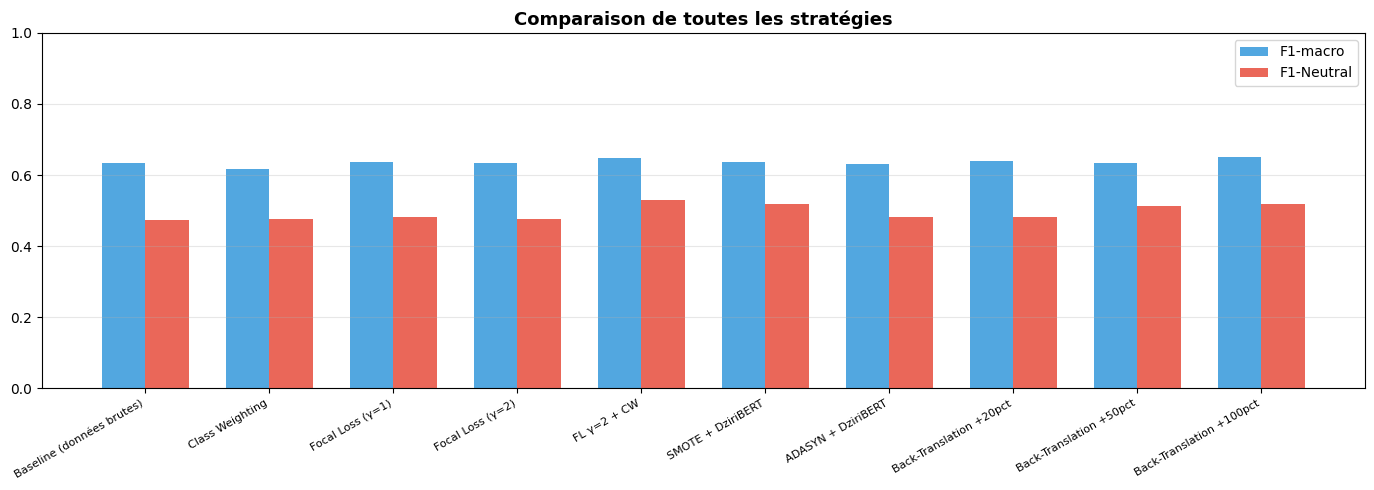

In [70]:
with open(os.path.join(WORK_DIR, 'results_comparison.json'), 'r') as f:
    final = json.load(f)
df_final = pd.DataFrame(final)
if 'params' in df_final.columns: df_final = df_final.drop(columns=['params'], errors='ignore')
print('=== TABLEAU FINAL TOUTES STRATÉGIES ===')
print(df_final.to_string(index=False))

# Visualisation synthétique
fig, ax = plt.subplots(figsize=(14, 5))
configs = df_final['configuration'].tolist()
f1m = df_final['f1_macro'].tolist()
f1n = df_final['f1_neutral'].tolist()
x = np.arange(len(configs)); w = 0.35
ax.bar(x - w/2, f1m, w, label='F1-macro', color='#3498db', alpha=0.85)
ax.bar(x + w/2, f1n, w, label='F1-Neutral', color='#e74c3c', alpha=0.85)
ax.set_title('Comparaison de toutes les stratégies', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(configs, rotation=30, ha='right', fontsize=8)
ax.set_ylim(0, 1); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('final_comparison.png', dpi=150); plt.show()


In [72]:
# ── Fallback: use professor params if grid search hasn't run yet ──────────────
try:
    best_params
except NameError:
    GS_CACHE = os.path.join(WORK_DIR, 'gridsearch_results.json')
    if os.path.isfile(GS_CACHE):
        with open(GS_CACHE, 'r') as f:
            gs_results = json.load(f)
        best_params = gs_results[0]['params']
        print(f'✅ Loaded best_params from cache: {best_params}')
    else:
        best_params = {'lr': 2e-5, 'warmup_ratio': 0.10, 'max_len': 128,
                       'weight_decay': 0.0, 'label_smoothing': 0.0}
        print(f'⚠️  Grid search not run — using professor default params: {best_params}')

⚠️  Grid search not run — using professor default params: {'lr': 2e-05, 'warmup_ratio': 0.1, 'max_len': 128, 'weight_decay': 0.0, 'label_smoothing': 0.0}


In [73]:
# ════════════════════════════════════════════════════════════════════════════
# BONUS — Noise-Aware Weighted Ensemble
# K-Fold OOF → Stacked meta-learner + weight grid search
# ════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

N_FOLDS    = 5
OOF_CACHE  = os.path.join(WORK_DIR, 'oof_predictions.pkl')

# ── Base models for ensemble ──────────────────────────────────────────────────
ENSEMBLE_CONFIGS = [
    {'name': 'FL_CW',   'ckpt': 'tuned_FLCW_best.pt',
     'loss': FocalLoss(gamma=2.0, alpha=class_weights.cpu()), 'max_len': best_params['max_len']},
    {'name': 'CW',      'ckpt': 'tuned_CW_best.pt',
     'loss': nn.CrossEntropyLoss(weight=class_weights),       'max_len': best_params['max_len']},
    {'name': 'Baseline','ckpt': 'tuned_Baseline_best.pt',
     'loss': nn.CrossEntropyLoss(),                            'max_len': best_params['max_len']},
]

def predict_proba_model(ckpt_fn, texts, max_len):
    load_path, _ = resolve_ckpt(ckpt_fn)
    if load_path is None:
        raise FileNotFoundError(f'{ckpt_fn} not found')
    model_e = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id).to(device)
    model_e.load_state_dict(torch.load(load_path, map_location=device), strict=False)
    model_e.eval()
    ds = TwiflDataset(texts, [0]*len(texts), main_tokenizer, max_len)
    ld = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    probs = []
    with torch.no_grad():
        for b in ld:
            out = model_e(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device))
            probs.extend(torch.softmax(out.logits, -1).cpu().numpy())
    return np.array(probs)

# Combine train+val for k-fold (test stays frozen)
X_tv = np.concatenate([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
print(f'Train+Val: {len(X_tv)} | Test (frozen): {len(X_test)}')

if os.path.isfile(OOF_CACHE):
    print(f'✅ OOF cache found — loading.')
    with open(OOF_CACHE, 'rb') as f:
        oof_data = pickle.load(f)
    oof_predictions = oof_data['oof']
    fold_metrics    = oof_data['fold_metrics']
else:
    print(f'🏋️  Running {N_FOLDS}-fold CV to generate OOF predictions...')
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    oof_predictions = np.zeros((len(X_tv), len(ENSEMBLE_CONFIGS) * 3))
    fold_metrics = {ec['name']: [] for ec in ENSEMBLE_CONFIGS}

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_tv, y_tv)):
        print(f'\n--- Fold {fold_idx+1}/{N_FOLDS} ---')
        X_tf, y_tf = X_tv[tr_idx], y_tv[tr_idx]
        X_vf, y_vf = X_tv[val_idx], y_tv[val_idx]

        for ec_idx, ec in enumerate(ENSEMBLE_CONFIGS):
            print(f'  Training [{ec["name"]}]...')
            fold_ckpt = os.path.join(WORK_DIR, f'fold{fold_idx+1}_{ec["name"]}.pt')
            torch.manual_seed(SEED)
            model_f = AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id).to(device)
            ld_tr = DataLoader(TwiflDataset(X_tf, y_tf, main_tokenizer, ec['max_len']),
                               batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
            opt_f = AdamW(model_f.parameters(), lr=best_params['lr'],
                          weight_decay=best_params['weight_decay'], eps=1e-8)
            tot_f = len(ld_tr) * EPOCHS
            sch_f = get_linear_schedule_with_warmup(opt_f, int(tot_f*best_params['warmup_ratio']), tot_f)

            best_loss_f, best_state_f = float('inf'), None
            for epoch in range(1, EPOCHS+1):
                loss_f = train_epoch(model_f, ld_tr, opt_f, sch_f, ec['loss'])
                if loss_f < best_loss_f:
                    best_loss_f  = loss_f
                    best_state_f = {k: v.cpu().clone() for k, v in model_f.state_dict().items()}
            model_f.load_state_dict({k: v.to(device) for k, v in best_state_f.items()})
            torch.save(best_state_f, fold_ckpt)

            # OOF proba
            ld_vf = DataLoader(TwiflDataset(X_vf, [0]*len(X_vf), main_tokenizer, ec['max_len']),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
            proba_f = []
            model_f.eval()
            with torch.no_grad():
                for b in ld_vf:
                    out = model_f(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device))
                    proba_f.extend(torch.softmax(out.logits, -1).cpu().numpy())
            proba_f = np.array(proba_f)

            col_s = ec_idx * 3
            oof_predictions[val_idx, col_s:col_s+3] = proba_f
            yp_f = proba_f.argmax(axis=1)
            fold_metrics[ec['name']].append({
                'f1_macro': f1_score(y_vf, yp_f, average='macro'),
                'f1_neutral': f1_score(y_vf, yp_f, average=None, labels=[0,1,2])[2]
            })
            print(f'    Val F1-macro: {fold_metrics[ec["name"]][-1]["f1_macro"]:.4f}')

    with open(OOF_CACHE, 'wb') as f:
        pickle.dump({'oof': oof_predictions, 'fold_metrics': fold_metrics, 'y': y_tv}, f)
    print(f'✅ OOF predictions saved.')

# OOF summary
print('\n=== K-FOLD OOF SUMMARY ===')
for ec in ENSEMBLE_CONFIGS:
    fms = [m['f1_macro']   for m in fold_metrics[ec['name']]]
    fns = [m['f1_neutral'] for m in fold_metrics[ec['name']]]
    print(f'[{ec["name"]}] F1-macro: {np.mean(fms):.4f} ± {np.std(fms):.4f} | F1-Neutral: {np.mean(fns):.4f} ± {np.std(fns):.4f}')

# ── Get test predictions from all base models ─────────────────────────────────
print('\nGenerating test set predictions...')
test_probas = {}
for ec in ENSEMBLE_CONFIGS:
    proba = predict_proba_model(ec['ckpt'], X_test, ec['max_len'])
    test_probas[ec['name']] = proba
    yp = proba.argmax(axis=1)
    print(f'  [{ec["name"]}] F1-macro: {f1_score(y_test, yp, average="macro"):.4f} | '
          f'F1-Neutral: {f1_score(y_test, yp, average=None, labels=[0,1,2])[2]:.4f}')

# ── Weight grid search on OOF ─────────────────────────────────────────────────
print('\nSearching best ensemble weights on OOF...')
oof_per_model = {ec['name']: oof_predictions[:, i*3:(i+1)*3] for i, ec in enumerate(ENSEMBLE_CONFIGS)}
weight_options = [0.1, 0.2, 0.3, 0.4, 0.5]
best_oof_f1, best_weights, best_nb = 0, None, 0

for w_combo in iproduct(weight_options, repeat=len(ENSEMBLE_CONFIGS)):
    if abs(sum(w_combo) - 1.0) > 0.01: continue
    for nb in [0.0, 0.1, 0.2, 0.3]:
        combined = sum(w * oof_per_model[ec['name']] for w, ec in zip(w_combo, ENSEMBLE_CONFIGS))
        combined = combined.copy()
        combined[:, 2] = (1 - nb) * combined[:, 2] + nb * oof_per_model['FL_CW'][:, 2]
        oof_f1 = f1_score(y_tv, combined.argmax(axis=1), average='macro')
        if oof_f1 > best_oof_f1:
            best_oof_f1, best_weights, best_nb = oof_f1, w_combo, nb

print(f'Best OOF F1-macro: {best_oof_f1:.4f}')
print(f'Best weights: {dict(zip([ec["name"] for ec in ENSEMBLE_CONFIGS], best_weights))}')
print(f'Best Neutral boost: {best_nb}')

# Apply to test
test_ens = sum(w * test_probas[ec['name']] for w, ec in zip(best_weights, ENSEMBLE_CONFIGS))
test_ens = test_ens.copy()
test_ens[:, 2] = (1 - best_nb) * test_ens[:, 2] + best_nb * test_probas['FL_CW'][:, 2]
test_ens_pred  = test_ens.argmax(axis=1)

# ── Stacked meta-learners ─────────────────────────────────────────────────────
meta_lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced', C=1.0)
meta_lr.fit(oof_predictions, y_tv)
meta_lr_proba = meta_lr.predict_proba(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))
meta_lr_pred  = meta_lr.predict(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))

meta_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED,
                         early_stopping=True, validation_fraction=0.1)
meta_mlp.fit(oof_predictions, y_tv)
meta_mlp_proba = meta_mlp.predict_proba(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))
meta_mlp_pred  = meta_mlp.predict(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))

# ── Final comparison ──────────────────────────────────────────────────────────
bonus_results = {
    'Noise-Aware Ensemble': (test_ens_pred, test_ens),
    'Stacked LR':           (meta_lr_pred,  meta_lr_proba),
    'Stacked MLP':          (meta_mlp_pred, meta_mlp_proba),
}

print('\n=== BONUS FINAL RESULTS ===')
print(f'{"Configuration":<35} | {"F1-macro":<10} | {"F1-Neutral":<12} | {"AUC-PR":<10} | {"G-mean":<10}')
print('-' * 85)
for name, (yp, yb) in bonus_results.items():
    f1m = f1_score(y_test, yp, average='macro')
    f1p = f1_score(y_test, yp, average=None, labels=[0,1,2])
    auc = compute_auc_pr(y_test, yb)
    gm  = compute_gmean(y_test, yp)
    print(f'{name:<35} | {f1m:<10.4f} | {f1p[2]:<12.4f} | {auc:<10.4f} | {gm:<10.4f}')

# Save
bonus_out = []
for name, (yp, yb) in bonus_results.items():
    f1m = f1_score(y_test, yp, average='macro')
    f1p = f1_score(y_test, yp, average=None, labels=[0,1,2])
    bonus_out.append({'configuration': name, 'f1_macro': round(f1m,4),
                      'f1_positive': round(f1p[0],4), 'f1_negative': round(f1p[1],4),
                      'f1_neutral': round(f1p[2],4),
                      'auc_pr': round(compute_auc_pr(y_test,yb),4),
                      'g_mean': round(compute_gmean(y_test,yp),4)})
with open(os.path.join(WORK_DIR, 'bonus_results.json'), 'w') as f:
    json.dump(bonus_out, f, indent=2, ensure_ascii=False)
print('✅ Saved bonus_results.json')

Train+Val: 3992 | Test (frozen): 705
🏋️  Running 5-fold CV to generate OOF predictions...

--- Fold 1/5 ---
  Training [FL_CW]...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

    Val F1-macro: 0.6876
  Training [CW]...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

    Val F1-macro: 0.6182
  Training [Baseline]...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

    Val F1-macro: 0.6316
✅ OOF predictions saved.

=== K-FOLD OOF SUMMARY ===
[FL_CW] F1-macro: 0.6481 ± 0.0338 | F1-Neutral: 0.5128 ± 0.0515
[CW] F1-macro: 0.6558 ± 0.0275 | F1-Neutral: 0.5150 ± 0.0474
[Baseline] F1-macro: 0.6526 ± 0.0221 | F1-Neutral: 0.5032 ± 0.0363

Generating test set predictions...


FileNotFoundError: tuned_FLCW_best.pt not found

In [74]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from itertools import product as iproduct

N_FOLDS   = 5
OOF_CACHE = os.path.join(WORK_DIR, 'oof_predictions.pkl')

ENSEMBLE_CONFIGS = [
    {'name': 'FL_CW',    'ckpt': 'combined_best.pt',  'loss': FocalLoss(gamma=2.0, alpha=class_weights.cpu()), 'max_len': MAX_LEN},
    {'name': 'CW',       'ckpt': 'cw_best.pt',         'loss': nn.CrossEntropyLoss(weight=class_weights),       'max_len': MAX_LEN},
    {'name': 'Baseline', 'ckpt': 'baseline_best.pt',   'loss': nn.CrossEntropyLoss(),                            'max_len': MAX_LEN},
]

def predict_proba_model(ckpt_fn, texts, max_len):
    # Try working dir first, then input dir
    candidates = [
        os.path.join(WORK_DIR, ckpt_fn),
        os.path.join(KAGGLE_INPUT_DIR, ckpt_fn),
    ]
    load_path = next((p for p in candidates if os.path.isfile(p)), None)
    if load_path is None:
        raise FileNotFoundError(f'{ckpt_fn} not found in {candidates}')
    print(f'    → loading from: {load_path}')
    model_e = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id).to(device)
    model_e.load_state_dict(torch.load(load_path, map_location=device), strict=False)
    model_e.eval()
    ds = TwiflDataset(texts, [0]*len(texts), main_tokenizer, max_len)
    ld = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    probs = []
    with torch.no_grad():
        for b in ld:
            out = model_e(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device))
            probs.extend(torch.softmax(out.logits, -1).cpu().numpy())
    return np.array(probs)

X_tv = np.concatenate([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

# ── Load OOF from cache — NO retraining ──────────────────────────────────────
print(f'Loading OOF cache...')
with open(OOF_CACHE, 'rb') as f:
    oof_data = pickle.load(f)
oof_predictions = oof_data['oof']
fold_metrics    = oof_data['fold_metrics']
print('✅ OOF loaded.')

print('\n=== K-FOLD OOF SUMMARY ===')
for ec in ENSEMBLE_CONFIGS:
    fms = [m['f1_macro']   for m in fold_metrics[ec['name']]]
    fns = [m['f1_neutral'] for m in fold_metrics[ec['name']]]
    print(f'[{ec["name"]}] F1-macro: {np.mean(fms):.4f} ± {np.std(fms):.4f} | F1-Neutral: {np.mean(fns):.4f} ± {np.std(fns):.4f}')

# ── Test predictions ──────────────────────────────────────────────────────────
print('\nGenerating test predictions...')
test_probas = {}
for ec in ENSEMBLE_CONFIGS:
    print(f'  [{ec["name"]}]')
    proba = predict_proba_model(ec['ckpt'], X_test, ec['max_len'])
    test_probas[ec['name']] = proba
    yp = proba.argmax(axis=1)
    print(f'  F1-macro: {f1_score(y_test, yp, average="macro"):.4f} | F1-Neutral: {f1_score(y_test, yp, average=None, labels=[0,1,2])[2]:.4f}')

# ── Weight grid search ────────────────────────────────────────────────────────
print('\nSearching best weights...')
oof_per_model = {ec['name']: oof_predictions[:, i*3:(i+1)*3] for i, ec in enumerate(ENSEMBLE_CONFIGS)}
weight_options = [0.1, 0.2, 0.3, 0.4, 0.5]
best_oof_f1, best_weights, best_nb = 0, None, 0

for w_combo in iproduct(weight_options, repeat=len(ENSEMBLE_CONFIGS)):
    if abs(sum(w_combo) - 1.0) > 0.01: continue
    for nb in [0.0, 0.1, 0.2, 0.3]:
        combined = sum(w * oof_per_model[ec['name']] for w, ec in zip(w_combo, ENSEMBLE_CONFIGS))
        combined = combined.copy()
        combined[:, 2] = (1 - nb) * combined[:, 2] + nb * oof_per_model['FL_CW'][:, 2]
        oof_f1 = f1_score(y_tv, combined.argmax(axis=1), average='macro')
        if oof_f1 > best_oof_f1:
            best_oof_f1, best_weights, best_nb = oof_f1, w_combo, nb

print(f'Best OOF F1-macro: {best_oof_f1:.4f}')
print(f'Best weights: {dict(zip([ec["name"] for ec in ENSEMBLE_CONFIGS], best_weights))}')
print(f'Best Neutral boost: {best_nb}')

test_ens = sum(w * test_probas[ec['name']] for w, ec in zip(best_weights, ENSEMBLE_CONFIGS))
test_ens = test_ens.copy()
test_ens[:, 2] = (1 - best_nb) * test_ens[:, 2] + best_nb * test_probas['FL_CW'][:, 2]
test_ens_pred  = test_ens.argmax(axis=1)

# ── Meta-learners ─────────────────────────────────────────────────────────────
meta_lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced', C=1.0)
meta_lr.fit(oof_predictions, y_tv)
meta_lr_proba = meta_lr.predict_proba(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))
meta_lr_pred  = meta_lr.predict(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))

meta_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED,
                         early_stopping=True, validation_fraction=0.1)
meta_mlp.fit(oof_predictions, y_tv)
meta_mlp_proba = meta_mlp.predict_proba(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))
meta_mlp_pred  = meta_mlp.predict(np.hstack([test_probas[ec['name']] for ec in ENSEMBLE_CONFIGS]))

# ── Final results ─────────────────────────────────────────────────────────────
bonus_results = {
    'Noise-Aware Ensemble': (test_ens_pred, test_ens),
    'Stacked LR':           (meta_lr_pred,  meta_lr_proba),
    'Stacked MLP':          (meta_mlp_pred, meta_mlp_proba),
}

print('\n=== BONUS FINAL RESULTS ===')
print(f'{"Configuration":<35} | {"F1-macro":<10} | {"F1-Neutral":<12} | {"AUC-PR":<10} | {"G-mean":<10}')
print('-' * 85)
for name, (yp, yb) in bonus_results.items():
    f1m = f1_score(y_test, yp, average='macro')
    f1p = f1_score(y_test, yp, average=None, labels=[0,1,2])
    auc = compute_auc_pr(y_test, yb)
    gm  = compute_gmean(y_test, yp)
    print(f'{name:<35} | {f1m:<10.4f} | {f1p[2]:<12.4f} | {auc:<10.4f} | {gm:<10.4f}')

bonus_out = []
for name, (yp, yb) in bonus_results.items():
    f1m = f1_score(y_test, yp, average='macro')
    f1p = f1_score(y_test, yp, average=None, labels=[0,1,2])
    bonus_out.append({'configuration': name, 'f1_macro': round(f1m,4),
                      'f1_positive': round(f1p[0],4), 'f1_negative': round(f1p[1],4),
                      'f1_neutral': round(f1p[2],4),
                      'auc_pr': round(compute_auc_pr(y_test,yb),4),
                      'g_mean': round(compute_gmean(y_test,yp),4)})
with open(os.path.join(WORK_DIR, 'bonus_results.json'), 'w') as f:
    json.dump(bonus_out, f, indent=2, ensure_ascii=False)
print('✅ Saved bonus_results.json')

Loading OOF cache...
✅ OOF loaded.

=== K-FOLD OOF SUMMARY ===
[FL_CW] F1-macro: 0.6481 ± 0.0338 | F1-Neutral: 0.5128 ± 0.0515
[CW] F1-macro: 0.6558 ± 0.0275 | F1-Neutral: 0.5150 ± 0.0474
[Baseline] F1-macro: 0.6526 ± 0.0221 | F1-Neutral: 0.5032 ± 0.0363

Generating test predictions...
  [FL_CW]
    → loading from: /kaggle/working/combined_best.pt


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  F1-macro: 0.6474 | F1-Neutral: 0.5304
  [CW]
    → loading from: /kaggle/input/models/fmyacine/ml/other/default/1/cw_best.pt


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  F1-macro: 0.6163 | F1-Neutral: 0.4766
  [Baseline]
    → loading from: /kaggle/input/models/fmyacine/ml/other/default/1/baseline_best.pt


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  F1-macro: 0.6350 | F1-Neutral: 0.4722

Searching best weights...
Best OOF F1-macro: 0.6559
Best weights: {'FL_CW': 0.2, 'CW': 0.4, 'Baseline': 0.4}
Best Neutral boost: 0.2

=== BONUS FINAL RESULTS ===
Configuration                       | F1-macro   | F1-Neutral   | AUC-PR     | G-mean    
-------------------------------------------------------------------------------------
Noise-Aware Ensemble                | 0.6503     | 0.5222       | 0.7338     | 0.6360    
Stacked LR                          | 0.6356     | 0.5073       | 0.7109     | 0.6408    
Stacked MLP                         | 0.6295     | 0.4715       | 0.7331     | 0.5446    
✅ Saved bonus_results.json


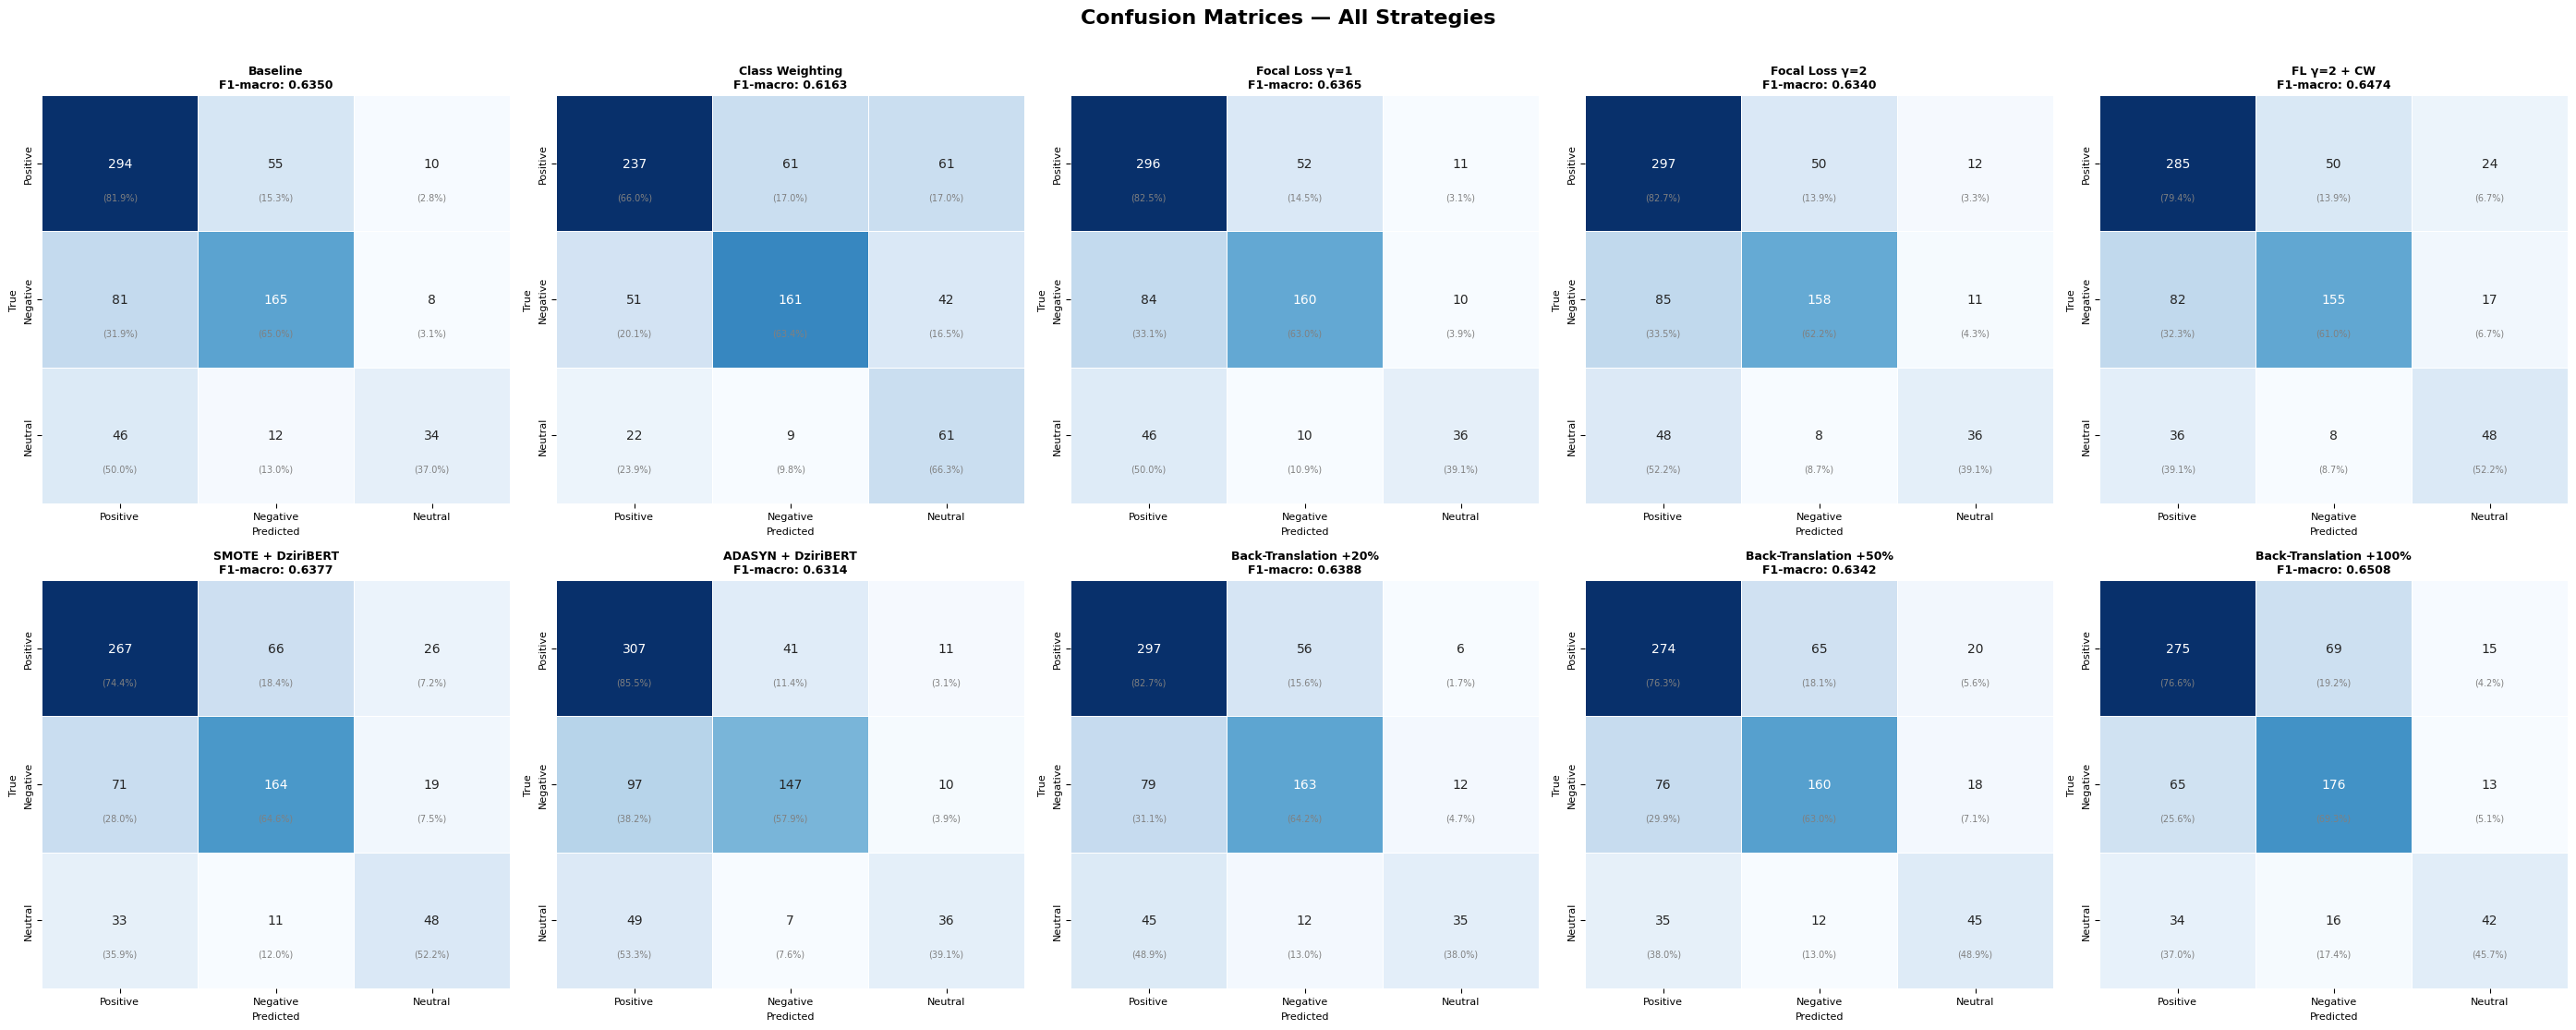

✅ Saved confusion_matrices_all.png


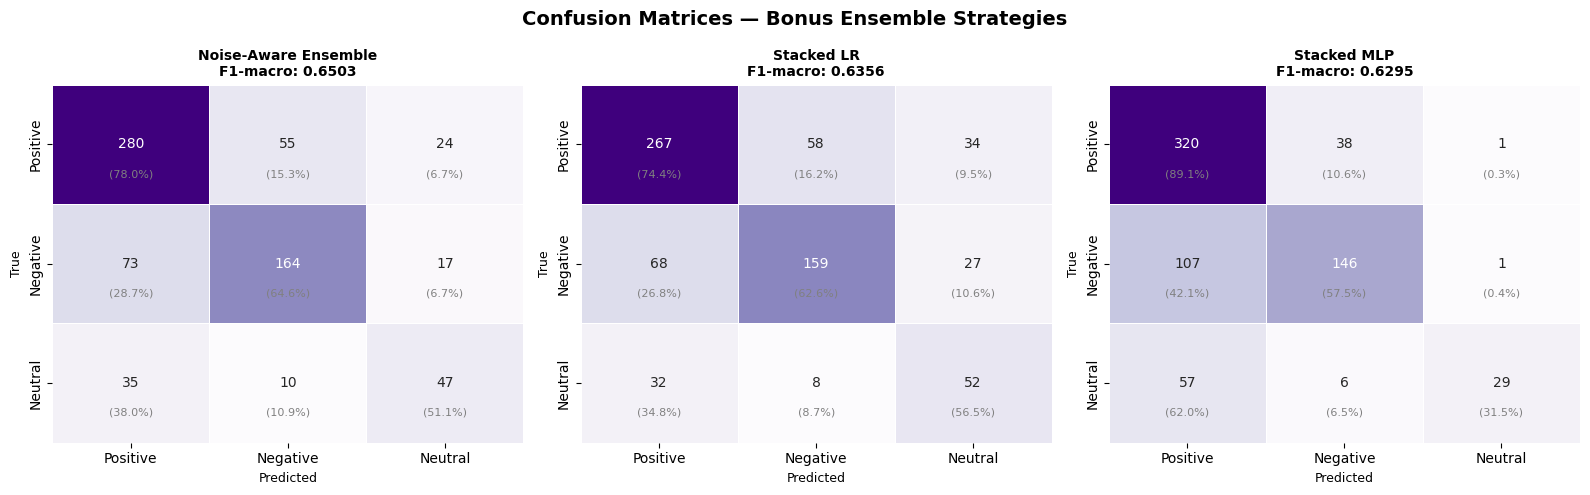

✅ Saved confusion_matrices_bonus.png


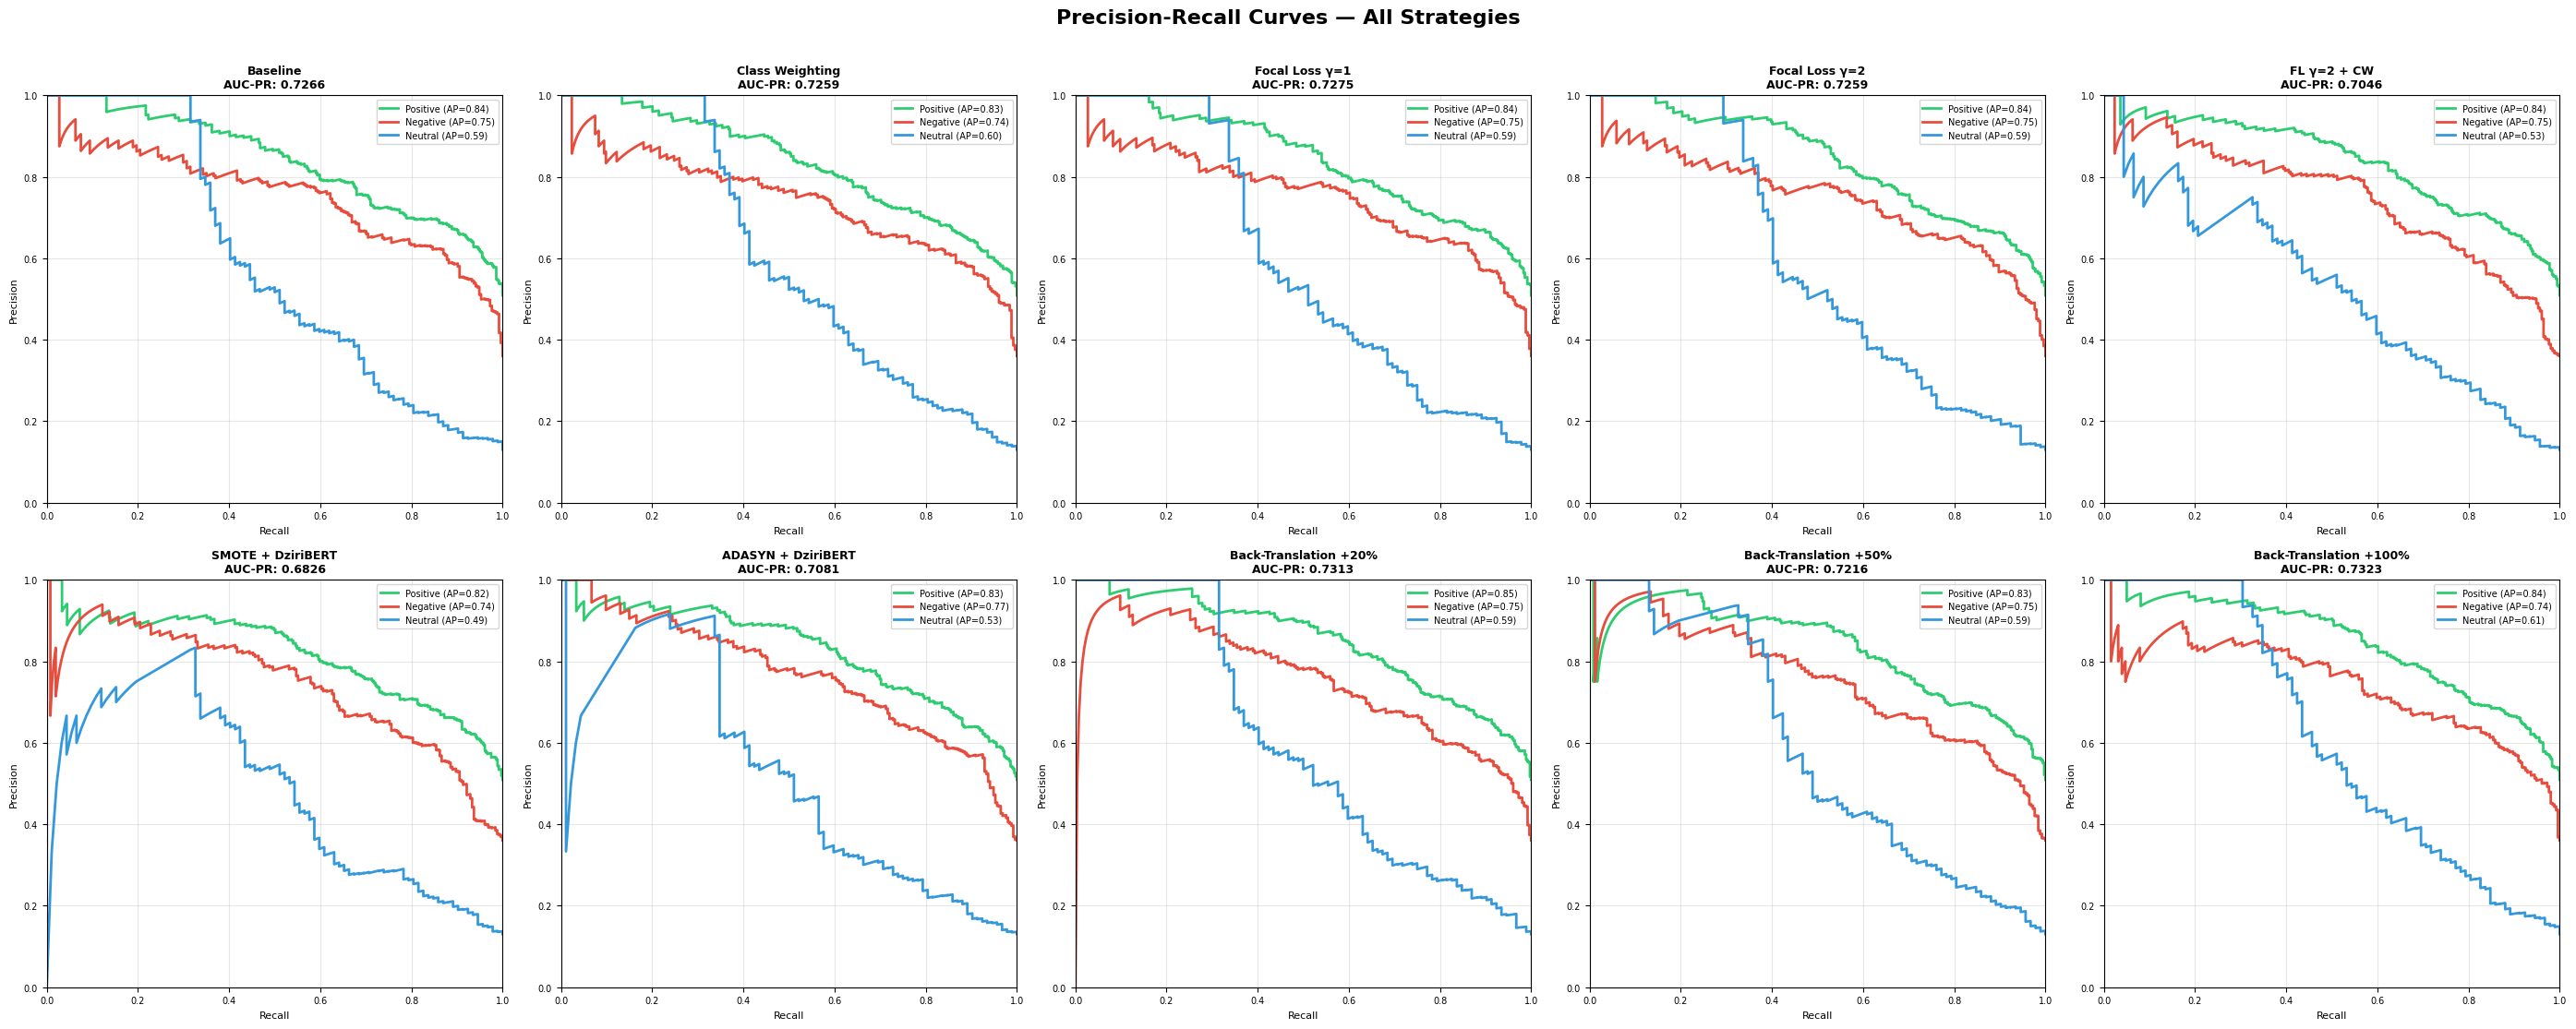

✅ Saved pr_curves_all.png


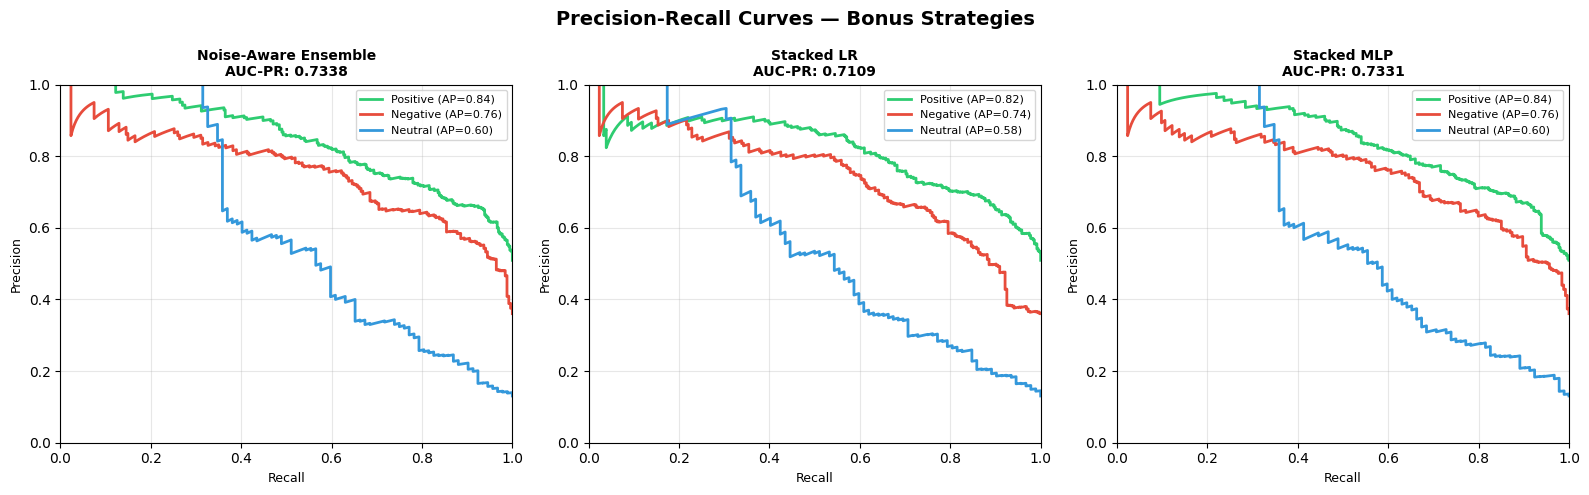

✅ Saved pr_curves_bonus.png

=== TABLEAU STATISTIQUE OBLIGATOIRE (Section 1.3) ===
  Classe  Nb exemples % du corpus Moy. mots Moy. caractères
Positive         2388       50.8%      11.1            76.8
Negative         1693       36.0%      13.8            91.6
 Neutral          616       13.1%      10.1            85.2
   TOTAL         4697        100%      11.9            83.2


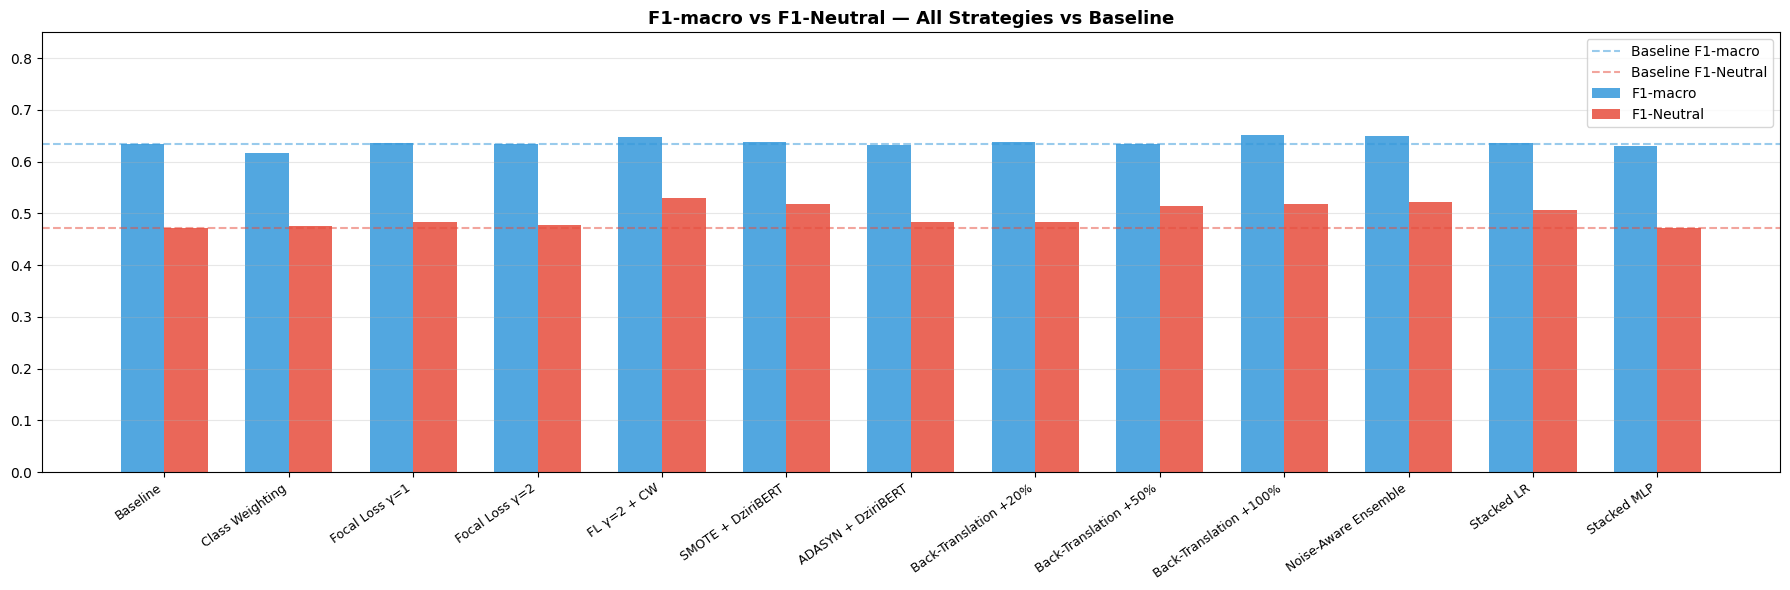

✅ Saved summary_f1_neutral.png

🎉 All visualizations done! Files saved:
  - confusion_matrices_all.png
  - confusion_matrices_bonus.png
  - pr_curves_all.png
  - pr_curves_bonus.png
  - summary_f1_neutral.png


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# ── All your results in one place ─────────────────────────────────────────────
CLASS_NAMES = ['Positive', 'Negative', 'Neutral']

all_configs = {
    'Baseline':              metrics_bl,
    'Class Weighting':       metrics_cw,
    'Focal Loss γ=1':        metrics_fl1,
    'Focal Loss γ=2':        metrics_fl2,
    'FL γ=2 + CW':           metrics_comb,
    'SMOTE + DziriBERT':     metrics_smote,
    'ADASYN + DziriBERT':    metrics_adasyn,
    'Back-Translation +20%': all_bt_metrics['20pct'],
    'Back-Translation +50%': all_bt_metrics['50pct'],
    'Back-Translation +100%':all_bt_metrics['100pct'],
}

bonus_configs = {
    'Noise-Aware Ensemble':  (test_ens_pred,  test_ens),
    'Stacked LR':            (meta_lr_pred,   meta_lr_proba),
    'Stacked MLP':           (meta_mlp_pred,  meta_mlp_proba),
}

# ══════════════════════════════════════════════════════════════════════════════
# 1. CONFUSION MATRICES — all strategies
# ══════════════════════════════════════════════════════════════════════════════
n_configs = len(all_configs)
fig, axes = plt.subplots(2, 5, figsize=(28, 11))
axes = axes.flatten()
fig.suptitle('Confusion Matrices — All Strategies', fontsize=16, fontweight='bold', y=1.01)

for idx, (name, m) in enumerate(all_configs.items()):
    cm = confusion_matrix(m['y_true'], m['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, linewidths=0.5)
    # Add percentage annotations
    for i in range(3):
        for j in range(3):
            axes[idx].text(j + 0.5, i + 0.75, f'({cm_pct[i,j]:.1f}%)',
                          ha='center', va='center', fontsize=7, color='gray')
    axes[idx].set_title(f'{name}\nF1-macro: {m["f1_macro"]:.4f}', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=8)
    axes[idx].set_ylabel('True', fontsize=8)
    axes[idx].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrices_all.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved confusion_matrices_all.png')

# ── Bonus confusion matrices ──────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Confusion Matrices — Bonus Ensemble Strategies', fontsize=14, fontweight='bold')

for idx, (name, (yp, yb)) in enumerate(bonus_configs.items()):
    cm = confusion_matrix(y_test, yp)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes2[idx],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, linewidths=0.5)
    for i in range(3):
        for j in range(3):
            axes2[idx].text(j + 0.5, i + 0.75, f'({cm_pct[i,j]:.1f}%)',
                           ha='center', va='center', fontsize=8, color='gray')
    f1m = f1_score(y_test, yp, average='macro')
    axes2[idx].set_title(f'{name}\nF1-macro: {f1m:.4f}', fontsize=10, fontweight='bold')
    axes2[idx].set_xlabel('Predicted', fontsize=9)
    axes2[idx].set_ylabel('True', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrices_bonus.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved confusion_matrices_bonus.png')

# ══════════════════════════════════════════════════════════════════════════════
# 2. PRECISION-RECALL CURVES — all strategies
# ══════════════════════════════════════════════════════════════════════════════
colors_pr = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}

fig3, axes3 = plt.subplots(2, 5, figsize=(28, 11))
axes3 = axes3.flatten()
fig3.suptitle('Precision-Recall Curves — All Strategies', fontsize=16, fontweight='bold', y=1.01)

for idx, (name, m) in enumerate(all_configs.items()):
    y_bin = label_binarize(m['y_true'], classes=[0, 1, 2])
    ax = axes3[idx]
    for i, cls in enumerate(CLASS_NAMES):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], m['y_proba'][:, i])
        ap = average_precision_score(y_bin[:, i], m['y_proba'][:, i])
        ax.plot(rec, prec, color=colors_pr[cls], linewidth=2, label=f'{cls} (AP={ap:.2f})')
    ax.set_title(f'{name}\nAUC-PR: {m["auc_pr"]:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=8)
    ax.set_ylabel('Precision', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'pr_curves_all.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved pr_curves_all.png')

# ── Bonus PR curves ───────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 3, figsize=(16, 5))
fig4.suptitle('Precision-Recall Curves — Bonus Strategies', fontsize=14, fontweight='bold')

for idx, (name, (yp, yb)) in enumerate(bonus_configs.items()):
    y_bin = label_binarize(y_test, classes=[0, 1, 2])
    ax = axes4[idx]
    for i, cls in enumerate(CLASS_NAMES):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], yb[:, i])
        ap = average_precision_score(y_bin[:, i], yb[:, i])
        ax.plot(rec, prec, color=colors_pr[cls], linewidth=2, label=f'{cls} (AP={ap:.2f})')
    auc = compute_auc_pr(y_test, yb)
    ax.set_title(f'{name}\nAUC-PR: {auc:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=9)
    ax.set_ylabel('Precision', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'pr_curves_bonus.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved pr_curves_bonus.png')

# ══════════════════════════════════════════════════════════════════════════════
# 3. MANDATORY EDA STATS TABLE (Section 1.3)
# ══════════════════════════════════════════════════════════════════════════════
print('\n=== TABLEAU STATISTIQUE OBLIGATOIRE (Section 1.3) ===')
stats_rows = []
for cls in CLASS_NAMES:
    subset = df[df[TARGET_COL] == cls]
    stats_rows.append({
        'Classe':         cls,
        'Nb exemples':    len(subset),
        '% du corpus':    f"{len(subset)/len(df)*100:.1f}%",
        'Moy. mots':      f"{subset['nb_mots'].mean():.1f}",
        'Moy. caractères':f"{subset['nb_chars'].mean():.1f}",
    })
stats_rows.append({
    'Classe':         'TOTAL',
    'Nb exemples':    len(df),
    '% du corpus':    '100%',
    'Moy. mots':      f"{df['nb_mots'].mean():.1f}",
    'Moy. caractères':f"{df['nb_chars'].mean():.1f}",
})
df_stats = pd.DataFrame(stats_rows)
print(df_stats.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# 4. FINAL SUMMARY BAR CHART (F1-Neutral focus)
# ══════════════════════════════════════════════════════════════════════════════
all_names = list(all_configs.keys()) + ['Noise-Aware Ensemble', 'Stacked LR', 'Stacked MLP']
all_f1m   = [m['f1_macro'] for m in all_configs.values()] + \
            [f1_score(y_test, yp, average='macro') for yp, _ in bonus_configs.values()]
all_f1n   = [m['f1_per_class'][2] for m in all_configs.values()] + \
            [f1_score(y_test, yp, average=None, labels=[0,1,2])[2] for yp, _ in bonus_configs.values()]

x = np.arange(len(all_names)); w = 0.35
fig5, ax5 = plt.subplots(figsize=(18, 6))
bars1 = ax5.bar(x - w/2, all_f1m, w, label='F1-macro',   color='#3498db', alpha=0.85)
bars2 = ax5.bar(x + w/2, all_f1n, w, label='F1-Neutral',  color='#e74c3c', alpha=0.85)
ax5.axhline(y=metrics_bl['f1_macro'],          color='#3498db', linestyle='--', alpha=0.5, label='Baseline F1-macro')
ax5.axhline(y=metrics_bl['f1_per_class'][2],   color='#e74c3c', linestyle='--', alpha=0.5, label='Baseline F1-Neutral')
ax5.set_title('F1-macro vs F1-Neutral — All Strategies vs Baseline', fontsize=13, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(all_names, rotation=35, ha='right', fontsize=9)
ax5.set_ylim(0, 0.85)
ax5.legend(fontsize=10)
ax5.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'summary_f1_neutral.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved summary_f1_neutral.png')

print('\n🎉 All visualizations done! Files saved:')
print('  - confusion_matrices_all.png')
print('  - confusion_matrices_bonus.png')
print('  - pr_curves_all.png')
print('  - pr_curves_bonus.png')
print('  - summary_f1_neutral.png')

In [76]:
# Complete final table with bonus
all_final = []
for name, m in all_configs.items():
    f1p = m['f1_per_class']
    all_final.append({'configuration': name, 'f1_macro': round(m['f1_macro'],4),
                      'f1_positive': round(f1p[0],4), 'f1_negative': round(f1p[1],4),
                      'f1_neutral': round(f1p[2],4), 'auc_pr': round(m['auc_pr'],4),
                      'g_mean': round(m['g_mean'],4)})

for name, (yp, yb) in bonus_configs.items():
    f1p = f1_score(y_test, yp, average=None, labels=[0,1,2])
    all_final.append({'configuration': name, 'f1_macro': round(f1_score(y_test, yp, average='macro'),4),
                      'f1_positive': round(f1p[0],4), 'f1_negative': round(f1p[1],4),
                      'f1_neutral': round(f1p[2],4), 'auc_pr': round(compute_auc_pr(y_test,yb),4),
                      'g_mean': round(compute_gmean(y_test,yp),4)})

df_final_complete = pd.DataFrame(all_final)
print(df_final_complete.to_string(index=False))
df_final_complete.to_csv(os.path.join(WORK_DIR, 'final_table_complete.csv'), index=False)
print('✅ Saved final_table_complete.csv')

         configuration  f1_macro  f1_positive  f1_negative  f1_neutral  auc_pr  g_mean
              Baseline    0.6350       0.7538       0.6790      0.4722  0.7266  0.5815
       Class Weighting    0.6163       0.7085       0.6639      0.4766  0.7259  0.6522
        Focal Loss γ=1    0.6365       0.7541       0.6723      0.4832  0.7275  0.5879
        Focal Loss γ=2    0.6340       0.7529       0.6723      0.4768  0.7259  0.5861
           FL γ=2 + CW    0.6474       0.7480       0.6638      0.5304  0.7046  0.6323
     SMOTE + DziriBERT    0.6377       0.7315       0.6626      0.5189  0.6826  0.6304
    ADASYN + DziriBERT    0.6314       0.7562       0.6548      0.4832  0.7081  0.5786
 Back-Translation +20%    0.6388       0.7615       0.6722      0.4828  0.7313  0.5867
 Back-Translation +50%    0.6342       0.7366       0.6517      0.5143  0.7216  0.6172
Back-Translation +100%    0.6508       0.7503       0.6835      0.5185  0.7323  0.6234
  Noise-Aware Ensemble    0.6503       0.74

In [19]:
# Load splits
with open(os.path.join(KAGGLE_INPUT_DIR, 'splits (1).pkl'), 'rb') as f:
    splits = pickle.load(f)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
label2id = splits['label2id']
id2label = {v: k for k, v in label2id.items()}

main_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Define class weights
from collections import Counter
counts = Counter(y_train)
total  = len(y_train)
n_cls  = len(counts)
class_weights = torch.tensor(
    [total / (n_cls * counts[i]) for i in range(n_cls)],
    dtype=torch.float
).to(device)
print('Class weights:', {id2label[i]: round(class_weights[i].item(), 4) for i in range(n_cls)})

Class weights: {'Positive': 0.6557, 'Negative': 0.9246, 'Neutral': 2.5422}


In [20]:
import json
from itertools import product as iproduct

GRIDSEARCH_CACHE = os.path.join(WORK_DIR, 'gridsearch_results.json')

param_grid = {
    'lr':           [1e-5, 2e-5, 3e-5],
    'warmup_ratio': [0.06, 0.10],
}

# Best loss function from your experiments
criterion_gs = FocalLoss(gamma=2.0, alpha=class_weights.cpu())

def train_and_evaluate_gs(lr, warmup_ratio, config_name):
    torch.manual_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
    ).to(device)

    loader_tr  = DataLoader(TwiflDataset(X_train, y_train, main_tokenizer, MAX_LEN),
                            batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    loader_val = DataLoader(TwiflDataset(X_val,   y_val,   main_tokenizer, MAX_LEN),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    loader_test= DataLoader(TwiflDataset(X_test,  y_test,  main_tokenizer, MAX_LEN),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    optimizer   = AdamW(model.parameters(), lr=lr, eps=1e-8)
    total_steps = len(loader_tr) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
                    optimizer, int(total_steps * warmup_ratio), total_steps)

    best_val_f1, best_state = 0, None
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, loader_tr, optimizer, scheduler, criterion_gs)
        vm   = evaluate(model, loader_val)
        print(f'    Epoch {epoch}/{EPOCHS} | Loss: {loss:.4f} | Val F1-macro: {vm["f1_macro"]:.4f} | Val F1-Neutral: {vm["f1_per_class"][2]:.4f}')
        if vm['f1_macro'] > best_val_f1:
            best_val_f1 = vm['f1_macro']
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    tm = evaluate(model, loader_test)

    # Save checkpoint
    ckpt_name = f'gs_{config_name}_best.pt'
    torch.save(best_state, os.path.join(WORK_DIR, ckpt_name))

    return {
        'config_name':   config_name,
        'lr':            lr,
        'warmup_ratio':  warmup_ratio,
        'val_f1_macro':  round(best_val_f1, 4),
        'f1_macro':      round(tm['f1_macro'], 4),
        'f1_positive':   round(tm['f1_per_class'][0], 4),
        'f1_negative':   round(tm['f1_per_class'][1], 4),
        'f1_neutral':    round(tm['f1_per_class'][2], 4),
        'auc_pr':        round(tm['auc_pr'], 4),
        'g_mean':        round(tm['g_mean'], 4),
        'ckpt':          ckpt_name,
    }

# ── Run grid search ───────────────────────────────────────────────────────────
if os.path.isfile(GRIDSEARCH_CACHE):
    print('✅ Grid search cache found — loading.')
    with open(GRIDSEARCH_CACHE, 'r') as f:
        gs_results = json.load(f)
else:
    gs_results = []
    combos = list(iproduct(param_grid['lr'], param_grid['warmup_ratio']))
    print(f'Running grid search: {len(combos)} combinations...')
    print(f'Estimated time: ~{len(combos) * 20} minutes\n')

    for lr, warmup_ratio in combos:
        config_name = f'lr{lr}_wr{warmup_ratio}'
        print(f'\n{"="*60}')
        print(f'Config: lr={lr} | warmup_ratio={warmup_ratio}')
        print(f'{"="*60}')
        result = train_and_evaluate_gs(lr, warmup_ratio, config_name)
        gs_results.append(result)
        print(f'  → Test F1-macro: {result["f1_macro"]} | F1-Neutral: {result["f1_neutral"]}')

        # Save after every combination so you don't lose progress
        with open(GRIDSEARCH_CACHE, 'w') as f:
            json.dump(gs_results, f, indent=2)
        print(f'  ✅ Progress saved ({len(gs_results)}/{len(combos)})')

# ── Results table ─────────────────────────────────────────────────────────────
print('\n=== GRID SEARCH RESULTS ===')
df_gs = pd.DataFrame(gs_results).sort_values('f1_neutral', ascending=False)
print(df_gs[['config_name','lr','warmup_ratio','f1_macro',
             'f1_positive','f1_negative','f1_neutral',
             'auc_pr','g_mean']].to_string(index=False))

# Best config
best = df_gs.iloc[0]
print(f'\n🏆 BEST CONFIG (by F1-Neutral):')
print(f'   lr={best["lr"]} | warmup_ratio={best["warmup_ratio"]}')
print(f'   F1-macro: {best["f1_macro"]} | F1-Neutral: {best["f1_neutral"]}')
print(f'   AUC-PR: {best["auc_pr"]} | G-mean: {best["g_mean"]}')

Running grid search: 6 combinations...
Estimated time: ~120 minutes


Config: lr=1e-05 | warmup_ratio=0.06


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

    Epoch 1/5 | Loss: 0.4036 | Val F1-macro: 0.6450 | Val F1-Neutral: 0.5050
    Epoch 2/5 | Loss: 0.2833 | Val F1-macro: 0.6363 | Val F1-Neutral: 0.5130
    Epoch 3/5 | Loss: 0.2072 | Val F1-macro: 0.6384 | Val F1-Neutral: 0.5085
    Epoch 4/5 | Loss: 0.1560 | Val F1-macro: 0.6569 | Val F1-Neutral: 0.5246
    Epoch 5/5 | Loss: 0.1252 | Val F1-macro: 0.6592 | Val F1-Neutral: 0.5327
  → Test F1-macro: 0.6507 | F1-Neutral: 0.5196
  ✅ Progress saved (1/6)

Config: lr=1e-05 | warmup_ratio=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

    Epoch 1/5 | Loss: 0.3902 | Val F1-macro: 0.6436 | Val F1-Neutral: 0.5128
    Epoch 2/5 | Loss: 0.2206 | Val F1-macro: 0.6446 | Val F1-Neutral: 0.5121
    Epoch 3/5 | Loss: 0.0900 | Val F1-macro: 0.6233 | Val F1-Neutral: 0.5392
    Epoch 4/5 | Loss: 0.0270 | Val F1-macro: 0.6620 | Val F1-Neutral: 0.5517
    Epoch 5/5 | Loss: 0.0098 | Val F1-macro: 0.6497 | Val F1-Neutral: 0.5333
  → Test F1-macro: 0.6352 | F1-Neutral: 0.5028
  ✅ Progress saved (5/6)

Config: lr=3e-05 | warmup_ratio=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

    Epoch 1/5 | Loss: 0.3967 | Val F1-macro: 0.6443 | Val F1-Neutral: 0.5088
    Epoch 2/5 | Loss: 0.2298 | Val F1-macro: 0.6437 | Val F1-Neutral: 0.5073
    Epoch 3/5 | Loss: 0.0928 | Val F1-macro: 0.6269 | Val F1-Neutral: 0.5339
    Epoch 4/5 | Loss: 0.0262 | Val F1-macro: 0.6628 | Val F1-Neutral: 0.5562
    Epoch 5/5 | Loss: 0.0102 | Val F1-macro: 0.6491 | Val F1-Neutral: 0.5311
  → Test F1-macro: 0.6382 | F1-Neutral: 0.5029
  ✅ Progress saved (6/6)

=== GRID SEARCH RESULTS ===
   config_name      lr  warmup_ratio  f1_macro  f1_positive  f1_negative  f1_neutral  auc_pr  g_mean
lr2e-05_wr0.06 0.00002          0.06    0.6577       0.7507       0.6751      0.5475  0.7025  0.6432
 lr2e-05_wr0.1 0.00002          0.10    0.6474       0.7480       0.6638      0.5304  0.7046  0.6323
 lr1e-05_wr0.1 0.00001          0.10    0.6546       0.7416       0.6976      0.5248  0.7308  0.6608
lr1e-05_wr0.06 0.00001          0.06    0.6507       0.7362       0.6962      0.5196  0.7313  0.6583
 lr3e-05_